# Importing and Code Cleaning

The JSON file can be opened and loaded using the loads function.

In [1]:
# Import the JSON file with the data
import json
import pandas as pd

# Read the file
fin = open("data.json", "r")
s = fin.read()
fin.close()

# Store the data using loads
data = json.loads(s)

Next we will create lists to store the data of each car. These lists will be become columns in the pandas dataframe.

In [2]:
# Lists to store Dataframe Column information
names = []          # Car Names
dos =   []          # Car Date of Sales
year =  []          # Car Year of Manufacturing
price = []          # Price of car
mileage = []        # Car Mileage
fuel = []           # Car Fuel Type
transmission = []   # Car Transmission Type
body = []           # Car Body Type
sale_loc = []       # County of Sale
description = []    # Car Description
brand_list = []     # Car Brand

# Start by iterating through each brand in the dataset
for brand in data.keys():
    # For each brand, iterate through each specific car
    for car in data[brand]:
        # Append data to lists
        names.append(car.get("name"))
        dos.append(car.get("Date of Sale"))
        brand_list.append(brand)
        year.append(car.get("Year"))
        price.append(car.get("Sale Price"))
        mileage.append(car.get("Mileage"))
        fuel.append(car.get("Fuel Type"))
        transmission.append(car.get("Transmission"))
        body.append(car.get("Body Type"))
        sale_loc.append(car.get("Sale Location"))
        description.append(car.get("Description"))
        
# Create dictionary from lists, storing data of each car        
d = {"Name": names, "Date of Sale": dos, "Year": year, 
     "Price": price, "Mileage": mileage, "Fuel Type": fuel, 
     "Transmission Type": transmission, "Body": body, "Sale Location": sale_loc, "Description": description, "Brand": brand_list}
        

# Create Pandas dataframe from dictionary
df = pd.DataFrame(d)
df


,Name,Date of Sale,Year,Price,Mileage,Fuel Type,Transmission Type,Body,Sale Location,Description,Brand
0,BMW 1 Series (116d),2025-01-02,2019,"€ 9,445.00","66,239 km",diesel,Automatic,Hatchback,Kerry,Grey BMW 1 Series. 1.5 116d SE Auto Euro 6 (s...,BMW
1,BMW 3 Series (SE Business Edition),02/01/2025,2012,"€ 6,495.00","166,517",Diesel,automatic,Estate,Galway,Silver BMW 3 Series. 2.0 320d SE Business Edi...,BMW
2,BMW X1 (SE),2025-01-03,2019,"€15,429.00","70,121",Diesel,Manual,SUV,Donegal,BMW X1. xDrive 18d SE 5dr Diesel Estate 2.0,BMW
3,BMW 8 Series (840d),05/01/2025,2022,"€ 58,023.00","16,906 km",Diesel,Automatic,Convertible,Dublin,Black BMW 8 Series. 840d xDrive Convertible 3...,BMW
4,BMW 4 Series Gran Coupe (420i),2025-01-07,2020,€20962.00,"54,026",petrol,automatic,Hatchback,Dublin,Blue BMW 4 Series Gran Coupe. 420i M Sport Gr...,BMW
...,...,...,...,...,...,...,...,...,...,...,...
1649,Volkswagen T-Roc (TSI EVO),2025-12-17,2022,"€23,379.00",17892,Petrol,manual,SUV,Cork,Green Volkswagen T-Roc. 2017 1.5 TSI SE 150PS...,Volkswagen
1650,Volkswagen Polo (Moda),18/12/2025,2012,"€ 3,802","178,967",Petrol,Manual,Hatchback,Clare,Volkswagen Polo. 1.2 Moda Euro 5 3dr. 4 previ...,Volkswagen
1651,Volkswagen Polo (SE),18/12/2025,2018,"9,743","61,509",Petrol,Manual,Hatchback,Wexford,White Volkswagen Polo. 1.2 SE TSI 3d 89 BHP 2...,Volkswagen
1652,Volkswagen Polo (GTI),21/12/2025,2018,€ 15288.00,"31,171",petrol,Manual,Hatchback,Meath,Red Volkswagen Polo. 1.8 TSI BlueMotion Tech ...,Volkswagen


Now we must clean the data, which involves reformating, standardising and setting the appropriate data types. Further discussion on this, and the challenges faced will be done at the bottom of this notebook. 

In [3]:
# Clean Dataset


############### Clean Date Info ###############

# Remove whitespaces from date of sale, store as string
df["Date of Sale"] = df["Date of Sale"].astype(str).str.strip()

# Rewrite all dates in DD-MM-YYYY format
df["Date of Sale"] = pd.to_datetime(df["Date of Sale"], errors='raise', dayfirst=True, format="mixed")

############### Clean Price Info ###############

# Remove EUR or € from all prices, and remove whitespace and commas. Store as floats
df["Price"] = df["Price"].astype(str).str.replace(",", "")
df["Price"] = df["Price"].astype(str).str.replace(" ", "")
df["Price"] = df["Price"].astype(str).str.replace("EUR", "")
df["Price"] = df["Price"].astype(str).str.replace("€", "")
df["Price"] = df["Price"].astype(float)

############### Clean Mileage Info ###############

# Remove whitespace, km and kms from mileage. Store as type float
df["Mileage"] = df["Mileage"].astype(str)
df["Mileage"] = df["Mileage"].str.replace(",", "")
df["Mileage"] = df["Mileage"].str.replace(" ", "")
df["Mileage"] = df["Mileage"].str.replace("kms", "")
df["Mileage"] = df["Mileage"].str.replace("km", "")
df["Mileage"] = df["Mileage"].astype(float)


############### Clean Transmission Info ###############

# Store in lower case, remove whitespace, replace auto with automatic
df["Transmission Type"] = df["Transmission Type"].astype(str).str.lower()
df["Transmission Type"] = df["Transmission Type"].str.replace(" ", "")
df["Transmission Type"] = df["Transmission Type"].replace("auto", "automatic")


############### Clean Fuel Info ###############

# Store in lower case, remove whitespace
df["Fuel Type"] = df["Fuel Type"].astype(str).str.lower()
df["Fuel Type"] = df["Fuel Type"].astype(str).str.replace(" ", "")

# If it contains "diesel" and "hybrid", change to "diesel-hybrid", if contains "petrol" and hybrid, change to "petrol-hybrid"
df.loc[df["Fuel Type"].str.contains("diesel") & df["Fuel Type"].str.contains("hybrid"), "Fuel Type"] = "diesel-hybrid"
df.loc[df["Fuel Type"].str.contains("petrol") & df["Fuel Type"].str.contains("hybrid"), "Fuel Type"] = "petrol-hybrid"

############### Clean Year Info ###############

# Store year as ints
df["Year"] = df["Year"].astype(int)


############### Clean Sale Location Info ###############

# Remove whitespace from sale location
df["Sale Location"] =  df["Sale Location"].str.strip()

############### Clean Body Info ###############
# Store body in lower case, remove whitespace
df["Body"] = df["Body"].astype(str).str.lower()
df["Body"] = df["Body"].astype(str).str.replace(" ", "")
# Replace "estat" with "estate", replace "s.u.v" with "suv"
df["Body"] = df["Body"].replace("estat", "estate")
df["Body"] = df["Body"].replace("s.u.v.", "suv")

############### Add additional columns from Description Info ###############
# Some descriptions contain colour and some have number of previous owners. Add these to the dataset as their own columns

# Adding colour info
colours = ["grey", "red", "black", "blue", "silver", "white", "green"] # List of colours
for colour in colours:
    # For each colours, make a mask of if that colours appears in the description. Then add that colour to the Colour column 
    mask = df["Description"].astype(str).str.lower().str.contains(colour, na=False)
    df.loc[mask, "Colour"] = colour 

# Add previous owner info
def extract_number_of_owners(description):
    # Function to extract the number of previous owners from description string. It always appears before 
    # the word previous if present
    split_desc = description.split(" ") # Split the description by spaces
    if "previous" in split_desc:
        # Return the number before previous if it exists
        previous_index = split_desc.index("previous")
        return(int(split_desc[previous_index -1]))
    else:
        # Otherwise return None
        return None
    
df["Previous Owners"] = df["Description"].apply(extract_number_of_owners)

# Add number of doors info
def extract_number_of_doors(description):
    # Function to extract the number of doors from description string. It always appears directly before 
    # "dr" if present, i.e. "4dr" will be in the description. We can split by spaces and check if any word contains "dr".
    split_desc = description.split(" ") # Split the description by spaces
    for word in split_desc:
        if "dr" in word:
            # If we find a word that contains "dr", we can extract the number before "dr" and return it as an int
            # Make sure that this is a number and not some random string
            number_of_doors = word.split("dr")[0]
            if number_of_doors.isdigit():
                return int(number_of_doors)
    # If none contain "dr" return 5, as most cars have 4 doors
    return 5

df["Number of Doors"] = df["Description"].apply(extract_number_of_doors)

df


,Name,Date of Sale,Year,Price,Mileage,Fuel Type,Transmission Type,Body,Sale Location,Description,Brand,Colour,Previous Owners,Number of Doors
0,BMW 1 Series (116d),2025-01-02,2019,9445.0,66239.0,diesel,automatic,hatchback,Kerry,Grey BMW 1 Series. 1.5 116d SE Auto Euro 6 (s...,BMW,grey,3.0,5
1,BMW 3 Series (SE Business Edition),2025-01-02,2012,6495.0,166517.0,diesel,automatic,estate,Galway,Silver BMW 3 Series. 2.0 320d SE Business Edi...,BMW,silver,2.0,5
2,BMW X1 (SE),2025-01-03,2019,15429.0,70121.0,diesel,manual,suv,Donegal,BMW X1. xDrive 18d SE 5dr Diesel Estate 2.0,BMW,NaN,NaN,5
3,BMW 8 Series (840d),2025-01-05,2022,58023.0,16906.0,diesel,automatic,convertible,Dublin,Black BMW 8 Series. 840d xDrive Convertible 3...,BMW,black,2.0,2
4,BMW 4 Series Gran Coupe (420i),2025-01-07,2020,20962.0,54026.0,petrol,automatic,hatchback,Dublin,Blue BMW 4 Series Gran Coupe. 420i M Sport Gr...,BMW,blue,1.0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1649,Volkswagen T-Roc (TSI EVO),2025-12-17,2022,23379.0,17892.0,petrol,manual,suv,Cork,Green Volkswagen T-Roc. 2017 1.5 TSI SE 150PS...,Volkswagen,green,1.0,5
1650,Volkswagen Polo (Moda),2025-12-18,2012,3802.0,178967.0,petrol,manual,hatchback,Clare,Volkswagen Polo. 1.2 Moda Euro 5 3dr. 4 previ...,Volkswagen,NaN,4.0,3
1651,Volkswagen Polo (SE),2025-12-18,2018,9743.0,61509.0,petrol,manual,hatchback,Wexford,White Volkswagen Polo. 1.2 SE TSI 3d 89 BHP 2...,Volkswagen,white,2.0,5
1652,Volkswagen Polo (GTI),2025-12-21,2018,15288.0,31171.0,petrol,manual,hatchback,Meath,Red Volkswagen Polo. 1.8 TSI BlueMotion Tech ...,Volkswagen,blue,2.0,5


This dataset does not contain too many missing values, the only missing values come from the data extracted from the description field.

In [4]:
#print any missing values
print(df.isnull().sum())

Name                   0
Date of Sale           0
Year                   0
Price                  0
Mileage                0
Fuel Type              0
Transmission Type      0
Body                   0
Sale Location          0
Description            0
Brand                  0
Colour               210
Previous Owners      686
Number of Doors        0
dtype: int64


# Analysis

## Geographical Plots

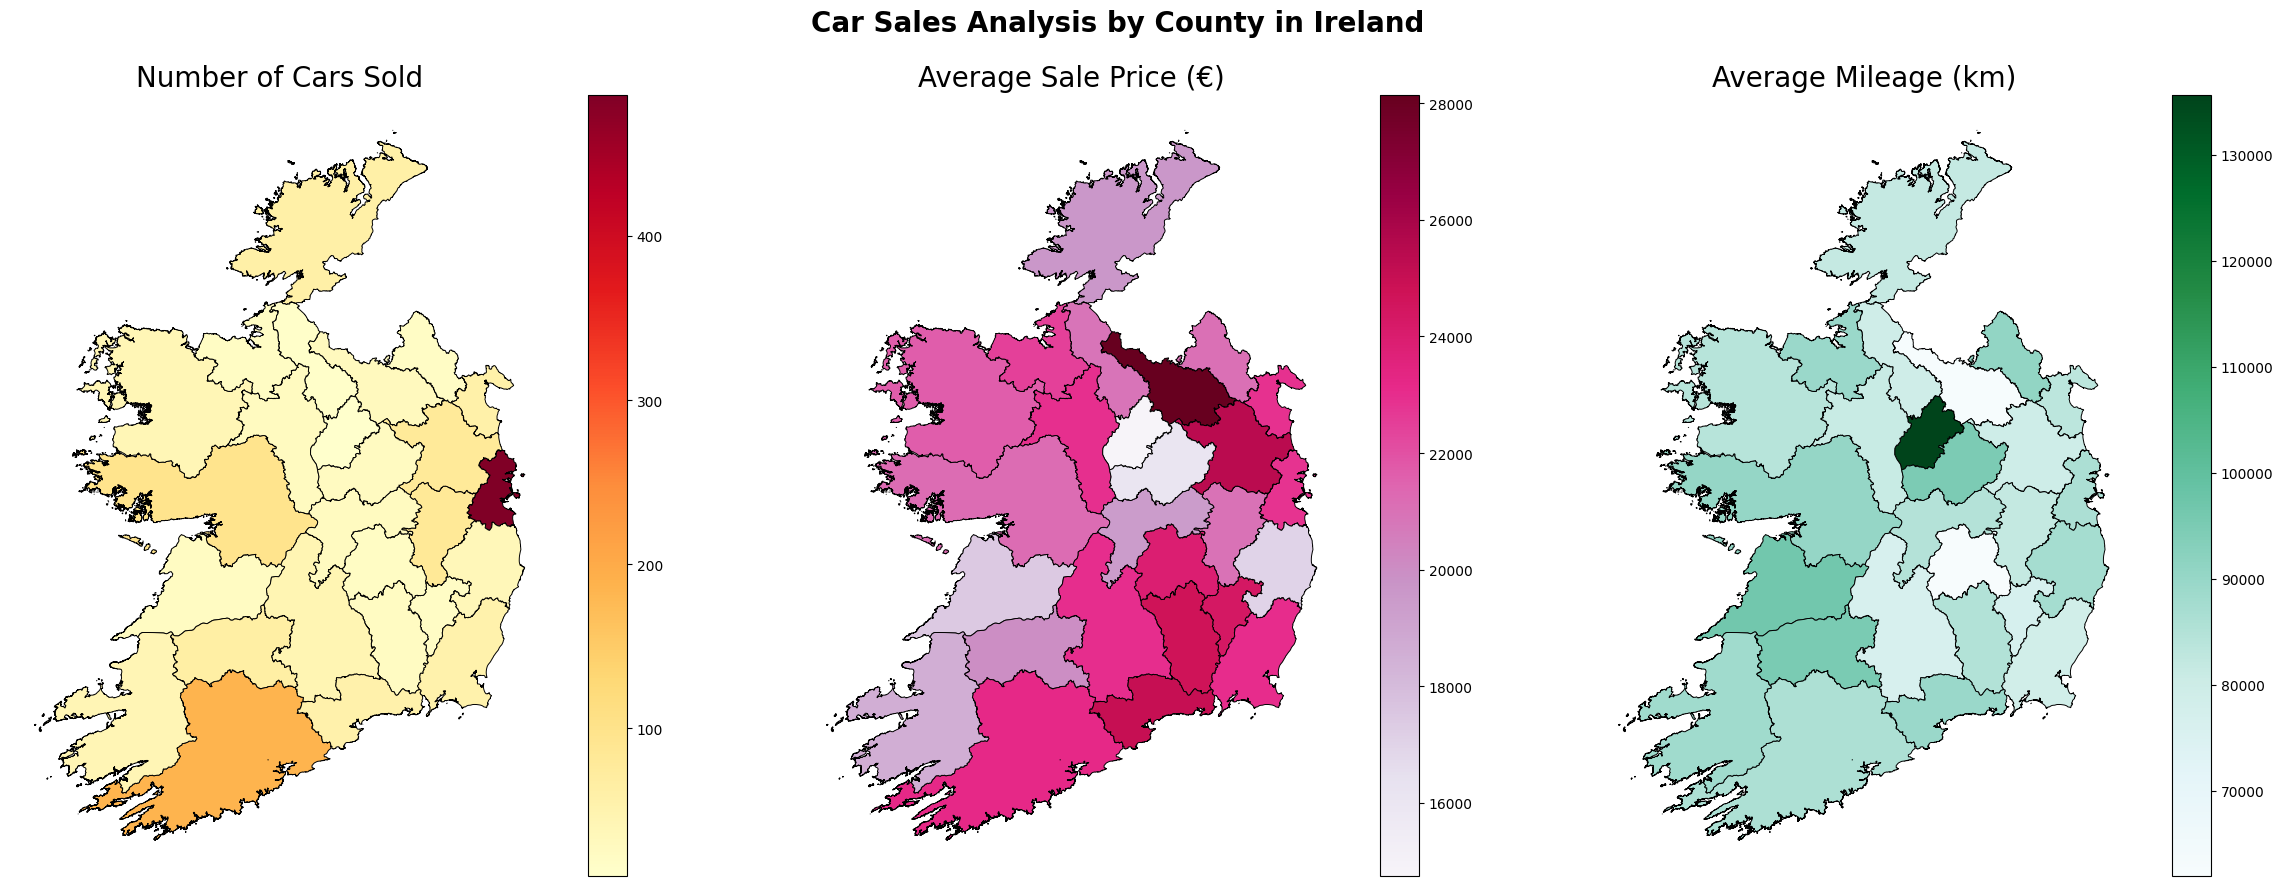

In [5]:
# Maps of Ireland Plots using Geopandas
import geopandas as gpd
import matplotlib.pyplot as plt

# Read GeoJSON file, stores boundary information for irish counties. This ireland class acts as a new dataframe
ireland = gpd.read_file("ireland-counties.geojson")

# Have to map undefined regions (i.e., Limerick City to Limerick) and remove "County" from everything
name_map = {
    "Limerick City": "Limerick",
    "Limerick County": "Limerick",
    "North Tipperary": "Tipperary",
    "South Tipperary": "Tipperary",
    "Waterford City": "Waterford",
    "Waterford County": "Waterford",
    "Galway City": "Galway",
    "Galway County": "Galway",
    "Dublin City": "Dublin",
    "South Dublin": "Dublin",
    "Fingal": "Dublin",
    "Dún Laoghaire-Rathdown": "Dublin",
    "Cork City": "Cork",
    "Cork County": "Cork",
}

def map_to_pandas_county_format(geopandas_name):
    # This function maps the geopandas county name to the name used in the dataset (i.e., County Clare just becomes Clare)
    county = name_map.get(geopandas_name, None) # If the name is in the name map, use it
    if county == None:
        # Otherwise, just remove "County" from it
        return geopandas_name.replace("County", "").strip()
    return county
    
# Add the sale location to the geopandas dataframe using the map_to_pandas_county_format() function
ireland["Sale Location"] = ireland["name"].map(map_to_pandas_county_format)
ireland = ireland.dissolve(by="Sale Location").reset_index() # Because both "Limerick City" and "Limerick County" become Limerick, they need to be combined

# Next, add the mileage price, and number of car sales to the ireland dataframe
# Make a dataframe of just the average mileage, average price, and number of car sales per county
avg_prices = df.groupby("Sale Location")["Price"].mean()
avg_mileage = df.groupby("Sale Location")["Mileage"].mean()
count = df["Sale Location"].value_counts()

# Merge the Dataframes, using inner merge
ireland = ireland.merge(avg_prices, on="Sale Location", how="inner")
ireland = ireland.merge(avg_mileage, on="Sale Location", how="inner")
ireland = ireland.merge(count, on="Sale Location", how="inner")

# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Car Sales Analysis by County in Ireland', fontsize=20, fontweight='bold', y=0.98)

# Plot the number of sales per county
ireland.plot(
    column="count",
    ax=axes[0],
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.7
 )
axes[0].set_title('Number of Cars Sold', fontsize=20)
axes[0].axis('off')

# Plot the average price per county
ireland.plot(
    column="Price",
    ax=axes[1],
    cmap="PuRd",
    legend=True,
    edgecolor="black",
    linewidth=0.7
 )
axes[1].set_title('Average Sale Price (€)', fontsize=20)
axes[1].axis('off')

# Plot the average mileage per county
ireland.plot(
    column="Mileage",
    ax=axes[2],
    cmap="BuGn",
    legend=True,
    edgecolor="black",
    linewidth=0.7
 )
axes[2].set_title('Average Mileage (km)', fontsize=20)
axes[2].axis('off')
axes[2].tick_params(axis="both", labelsize=14, length=6, width=1.5)



plt.tight_layout(rect=[0, 0, 1, 0.95])

### Discussion 

The leftmost plot clearly shows that Dublin is the county with the most car sales, and by a considerable margin. In total, 486 cars were sold in Dublin, with Cork being the next largest with 185 car sales. This is to be expected, as Dublin is the most populated county in Ireland. Longford and Lietrim are at the bottom of the table, with 10 and 15 car sales respectively. This makes sense, as they are the two least populated counties in Ireland. 

County Cavan is the county with the most expensive average car price, followed by Meath and Waterford. County Longford is the cheapest county to buy a car, however the low number of cars sold there might indicate that this is not an accurate measurement. 

Longford is also the county with the highest average mileage per car sold, with an average mileage of 135664.7km. This might indicate why the cars sold there are cheaper.

## Fuel Type Plot

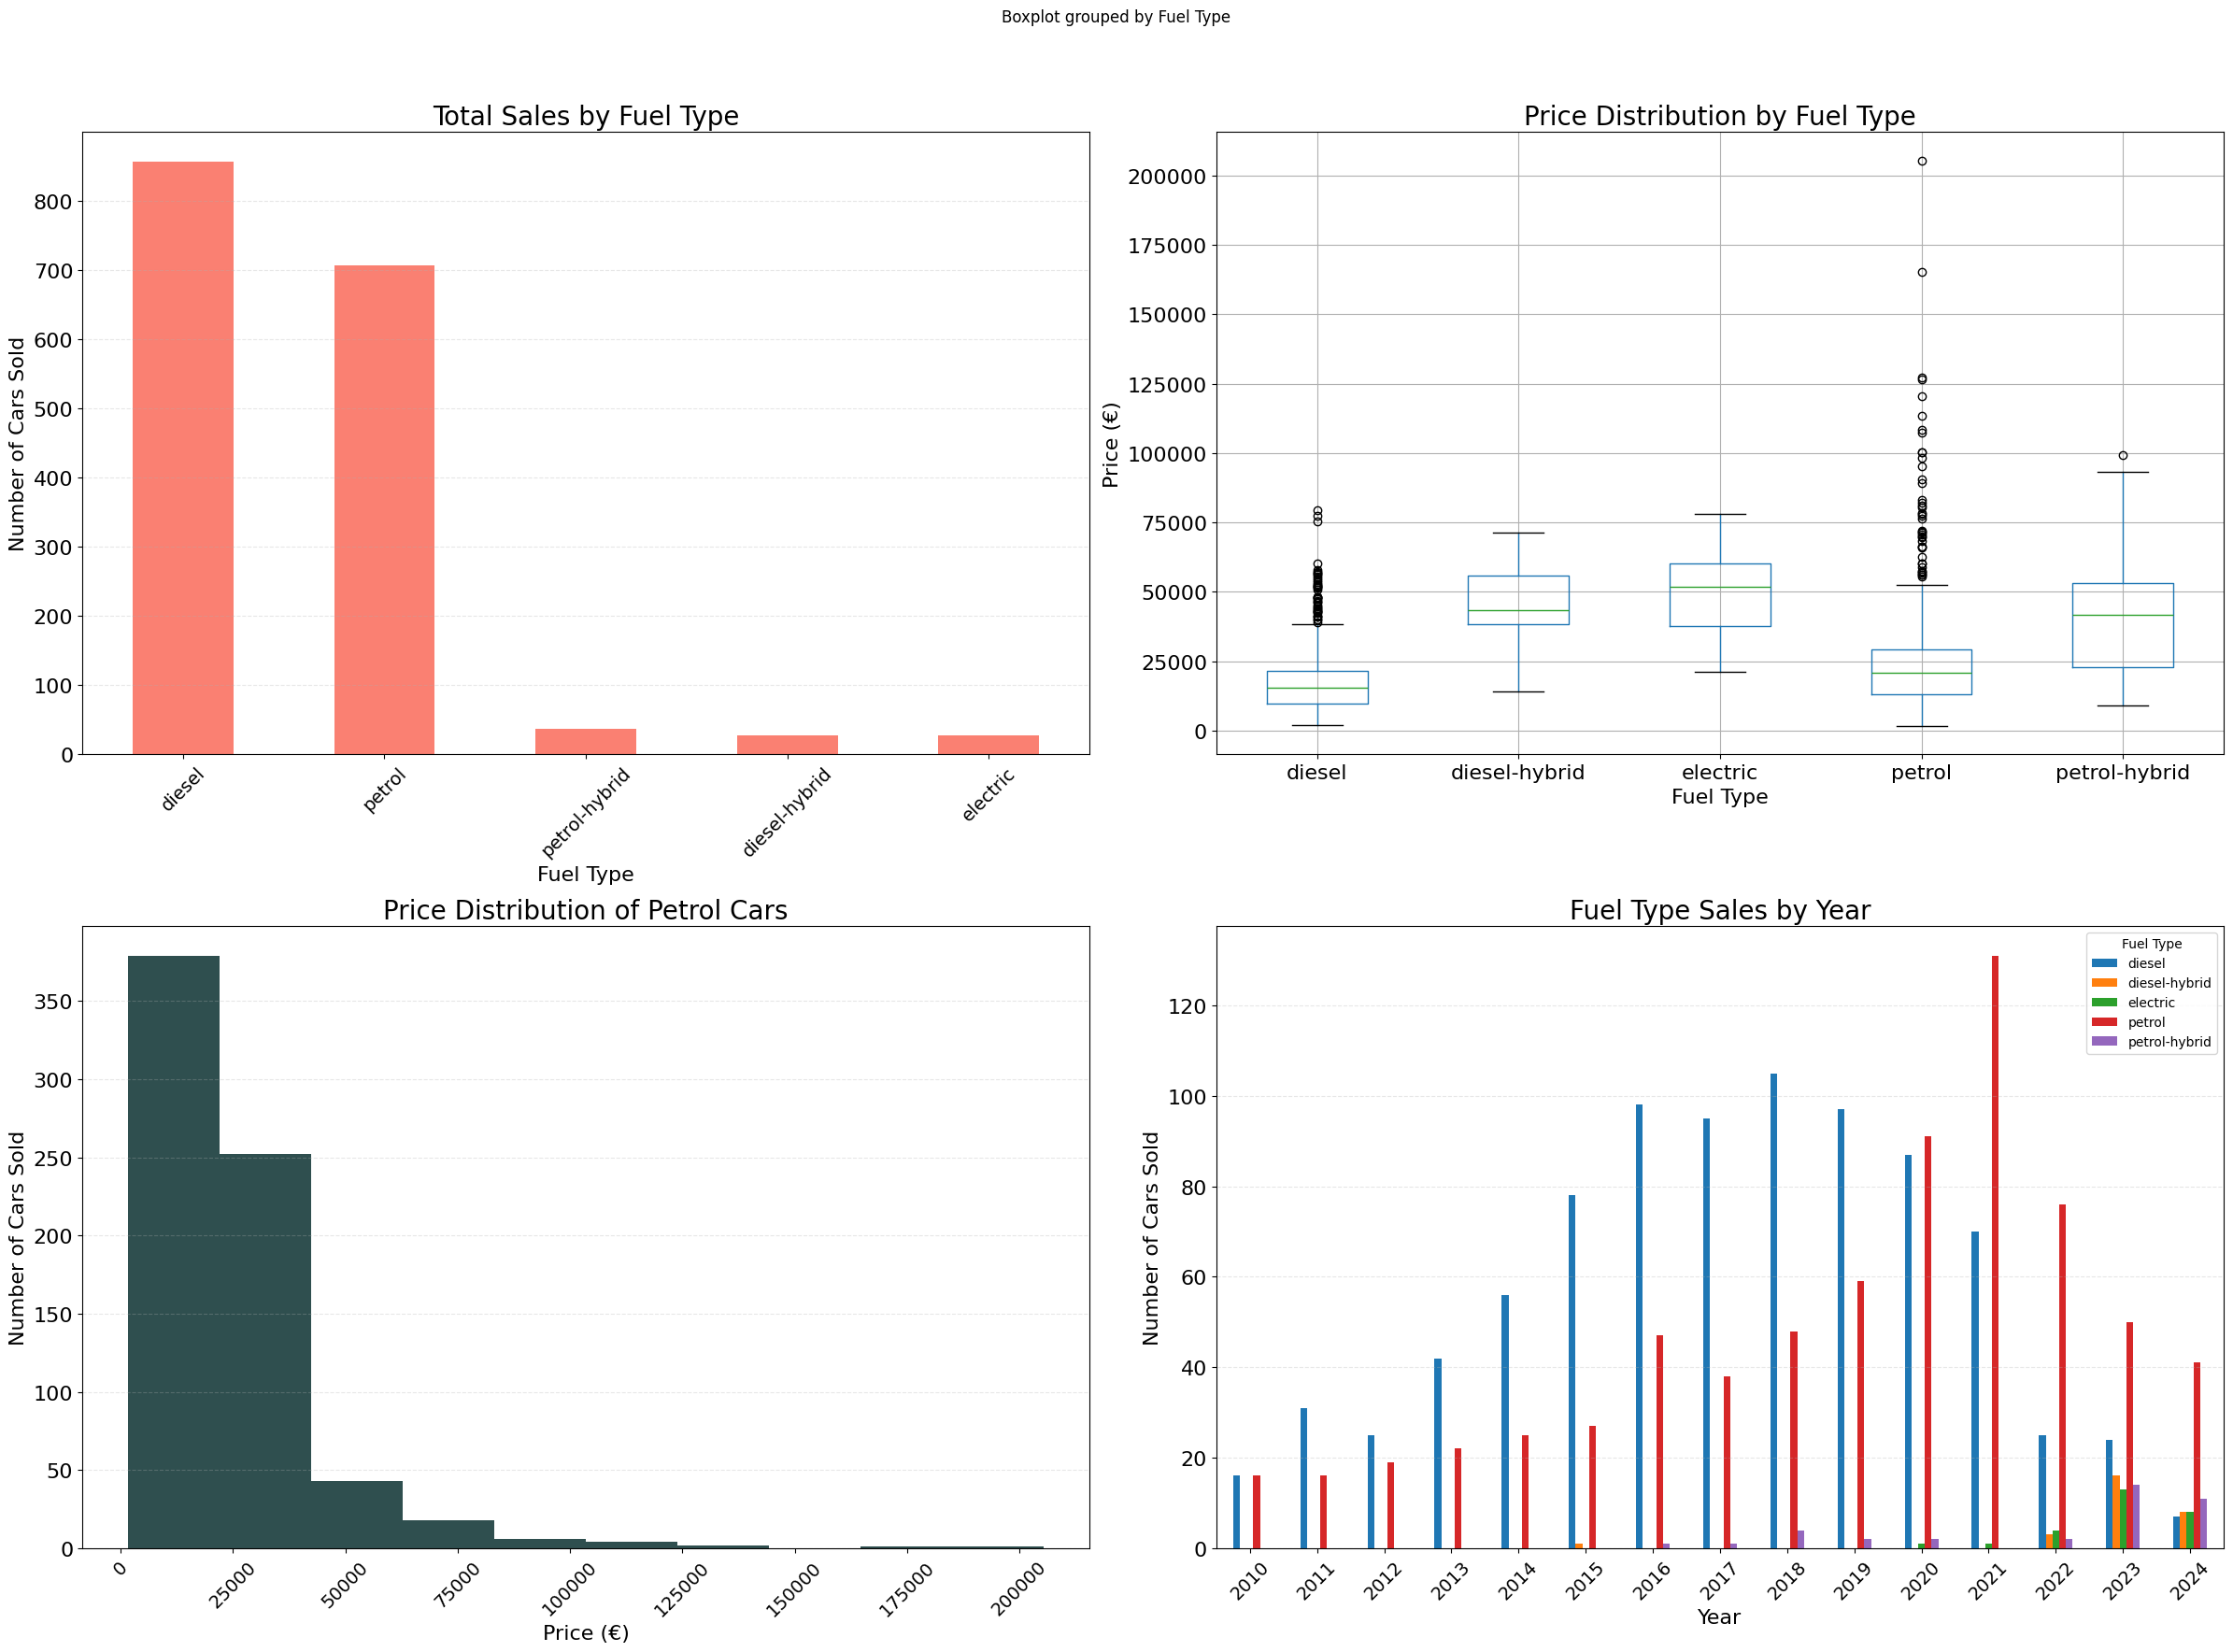

In [6]:
# One figure with 3 subplots
fig, axes = plt.subplots(2, 2, figsize=(24, 18))
axes = axes.flatten()
fig.suptitle('Fuel Type Analysis', fontsize=20, fontweight='bold', y=0.98)

# Plot the total number of each Fuel type sold
df["Fuel Type"].value_counts().plot(kind="bar", ax = axes[0], color='salmon')
axes[0].set_title('Total Sales by Fuel Type', fontsize=20)
axes[0].set_xlabel('Fuel Type', fontsize=16)
axes[0].set_ylabel('Number of Cars Sold', fontsize=16)
axes[0].tick_params(axis='x', rotation=45, labelsize=14)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')

# Compare the price of different fuel types
df.boxplot(column="Price",
           by="Fuel Type",
           ax = axes[1])
axes[1].set_title('Price Distribution by Fuel Type', fontsize=20)
axes[1].set_xlabel('Fuel Type', fontsize=16)
axes[1].set_ylabel('Price (€)', fontsize=16)
axes[1].tick_params(axis='both', labelsize=16)
plt.xticks(rotation=45)
fig.canvas.draw()

# Add another plot to show a histogram of the distribution of price of petrol cars sold
df[df["Fuel Type"] == "petrol"]["Price"].plot(kind="hist", ax=axes[2], color='darkslategrey')
axes[2].set_title('Price Distribution of Petrol Cars', fontsize=20)
axes[2].set_xlabel('Price (€)', fontsize=16)
axes[2].set_ylabel('Number of Cars Sold', fontsize=16)
axes[2].tick_params(axis='x', rotation=45, labelsize=14)
axes[2].tick_params(axis='y', labelsize=16)
axes[2].grid(True, axis='y', alpha=0.3, linestyle='--')


# Compare the number of each fuel type sold per year
# Using unstack here changes it from a dataframe with year, fuel type and count as the columns to 
# one with year, diesel, petrol etc. as the columns with the counts as the entries

df.groupby("Year")["Fuel Type"].value_counts().unstack().plot(kind="bar", ax= axes[3])
axes[3].set_title('Fuel Type Sales by Year', fontsize=20)
axes[3].set_xlabel('Year', fontsize=16)
axes[3].set_ylabel('Number of Cars Sold', fontsize=16)
axes[3].tick_params(axis='x', rotation=45, labelsize=14)
axes[3].tick_params(axis='y', labelsize=16)
axes[3].grid(True, axis='y', alpha=0.3, linestyle='--')

plt.tight_layout(rect=[0, 0, 1, 0.95])

### Discussion

Diesel cars are the most popular, with 856 diesel cars being sold (51.75%). This is followed closely by petrol, of which 706 (42.68%) were sold. Petrol-hydrib and diesel hybrid are less popular, and electric is less popular again, making up the remaining 5.5% of cars sold.

The box plot of price distribution shows that there is a large distribution in the price of petrol cars sold. This is exemplified by the bottom left plot, which shows that the petrol price data is right skewed. The same goes for diesel cars, although the price distribution is smaller. The other fuel types have less statistical outliers, and are better defined by a normal distribution. Electric cars are the most expensive on average, with a mean price of €50,437. On average, diesel cars are the cheapest with a mean price of €17,542.

The final graph shows that the number of new non petrol and diesel cars is growing. This could be because less electric and hybrid cars were produced before. Further discussion of the relationship between price and year of manufacturing will be done later.

# Brand Plots

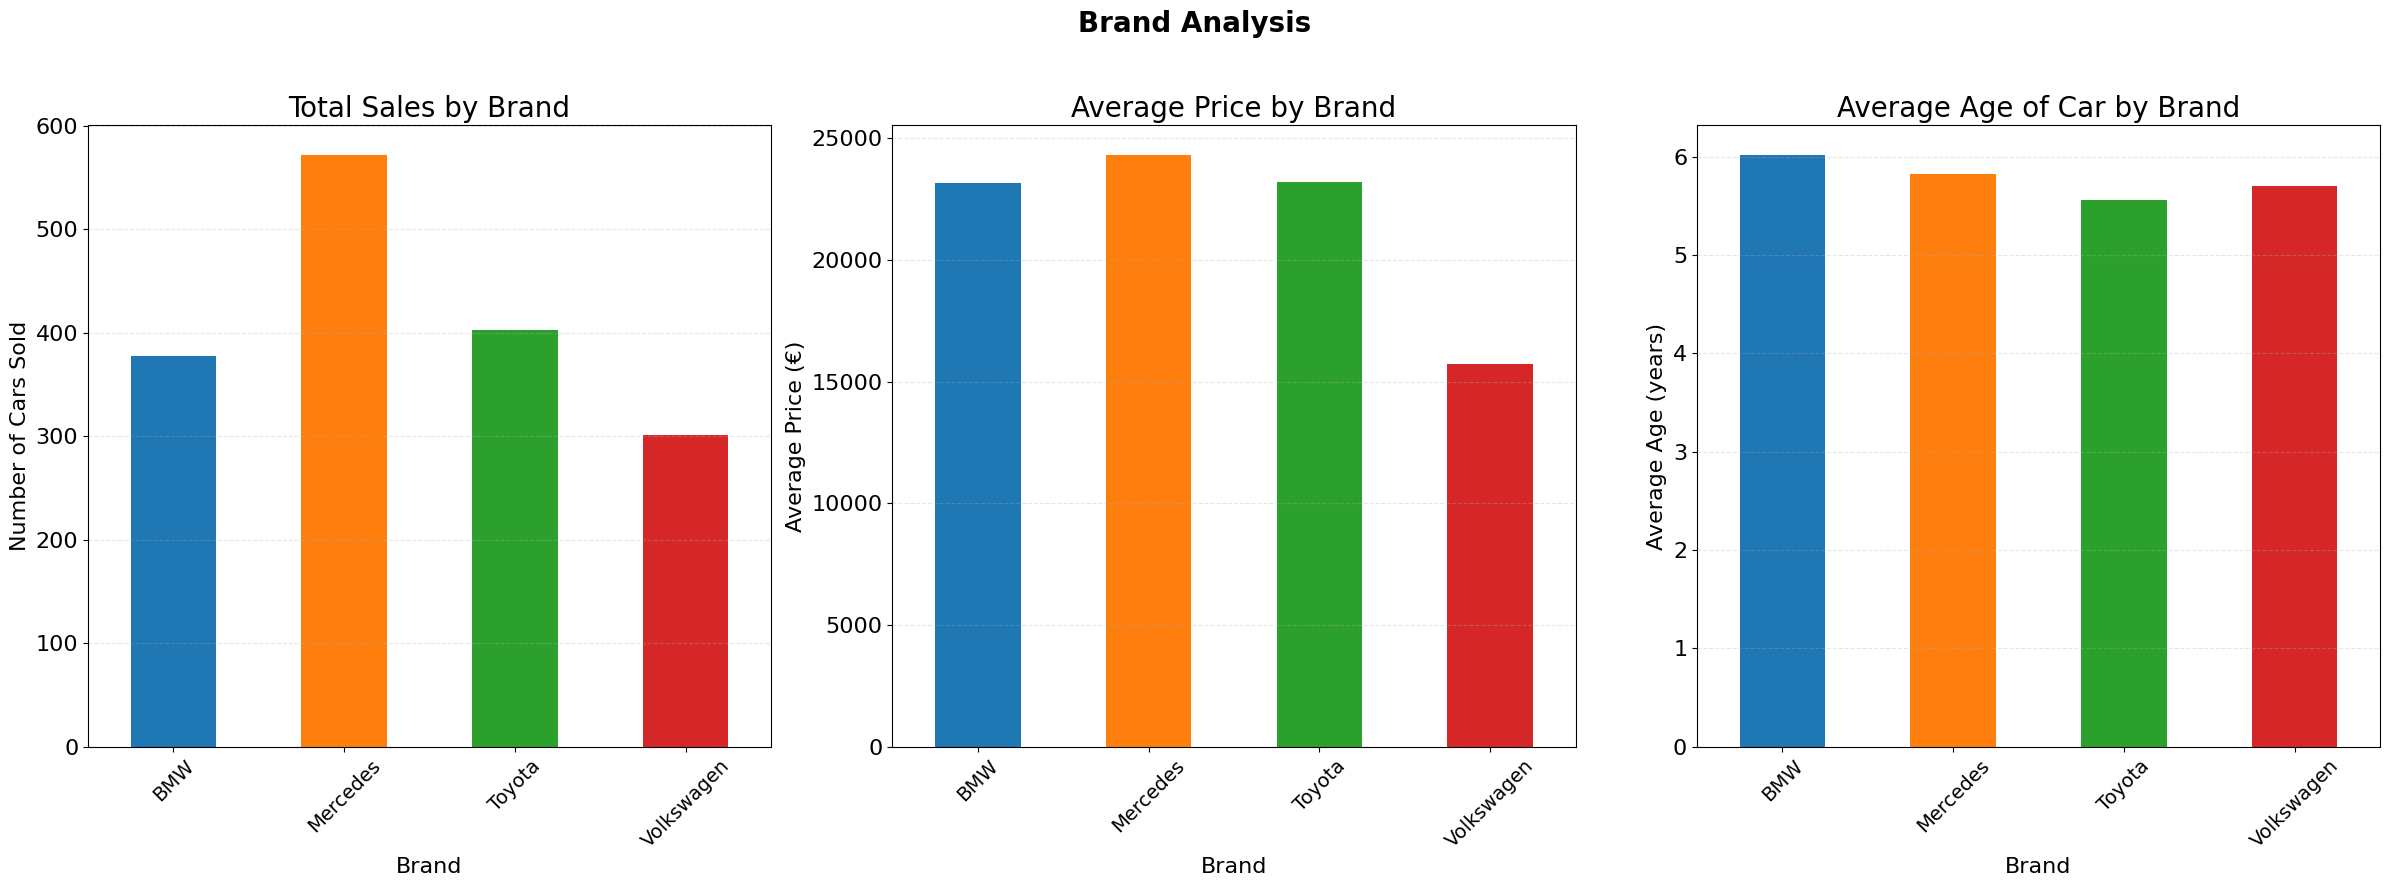

In [7]:
# Brand analysis
# three plots. 1. number of each car brand sold, 2. Price of each brand, 3. Avg. age per brand

# Set brand colours across all graphs
brand_colours = {
    'BMW': '#1f77b4',
    'Mercedes': '#ff7f0e',
    'Toyota': '#2ca02c',     
    'Volkswagen': '#d62728'  
}

# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))


# Get brand value counts and map colours to match the order
brand_counts = df["Brand"].value_counts().sort_index()
colours_for_bars = [brand_colours[brand] for brand in brand_counts.index]
brand_counts.plot(kind="bar", ax = axes[0], color=colours_for_bars)
axes[0].set_title('Total Sales by Brand', fontsize=20)
axes[0].set_xlabel('Brand', fontsize=16)
axes[0].set_ylabel('Number of Cars Sold', fontsize=16)
axes[0].tick_params(axis='x', rotation=45, labelsize=14)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')

# Plot the average price per car brand
avg_prices_by_brand = df.groupby("Brand")["Price"].mean()
colours_for_price_bars = [brand_colours[brand] for brand in avg_prices_by_brand.index]
avg_prices_by_brand.plot(kind="bar", ax=axes[1], color=colours_for_price_bars)
axes[1].set_title('Average Price by Brand', fontsize=20)
axes[1].set_xlabel('Brand', fontsize=16)
axes[1].set_ylabel('Average Price (€)', fontsize=16)
axes[1].tick_params(axis='x', rotation=45, labelsize=14)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].grid(True, axis='y', alpha=0.3, linestyle='--')

df["Age"] = df["Year"].max() -  df["Year"]

avg_age_by_brand = df.groupby("Brand")["Age"].mean()
colours_for_age_bars = [brand_colours[brand] for brand in avg_age_by_brand.index]
avg_age_by_brand.plot(kind="bar", ax=axes[2], color=colours_for_age_bars)
axes[2].set_title('Average Age of Car by Brand', fontsize=20)
axes[2].set_xlabel('Brand', fontsize=16)
axes[2].set_ylabel('Average Age (years)', fontsize=16)
axes[2].tick_params(axis='x', rotation=45, labelsize=14)
axes[2].tick_params(axis='y', labelsize=16)
axes[2].grid(True, axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Brand Analysis', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])

## Discussion

Mercedes were the most popular car brand sold, with 572 cars sold. Volkswagen were the least popular, only selling 301 cars. Interesting, Mercedes were also the most expensive car brand on average, with a mean price of €24320.68, while Volkswagen were the chepeast with a mean price of €15726.53. The average age of each car brand sold is pretty consistent between 5 and 6 years, however on average people buy newer Toyotas, and older BMWs.

# Transmission Plots

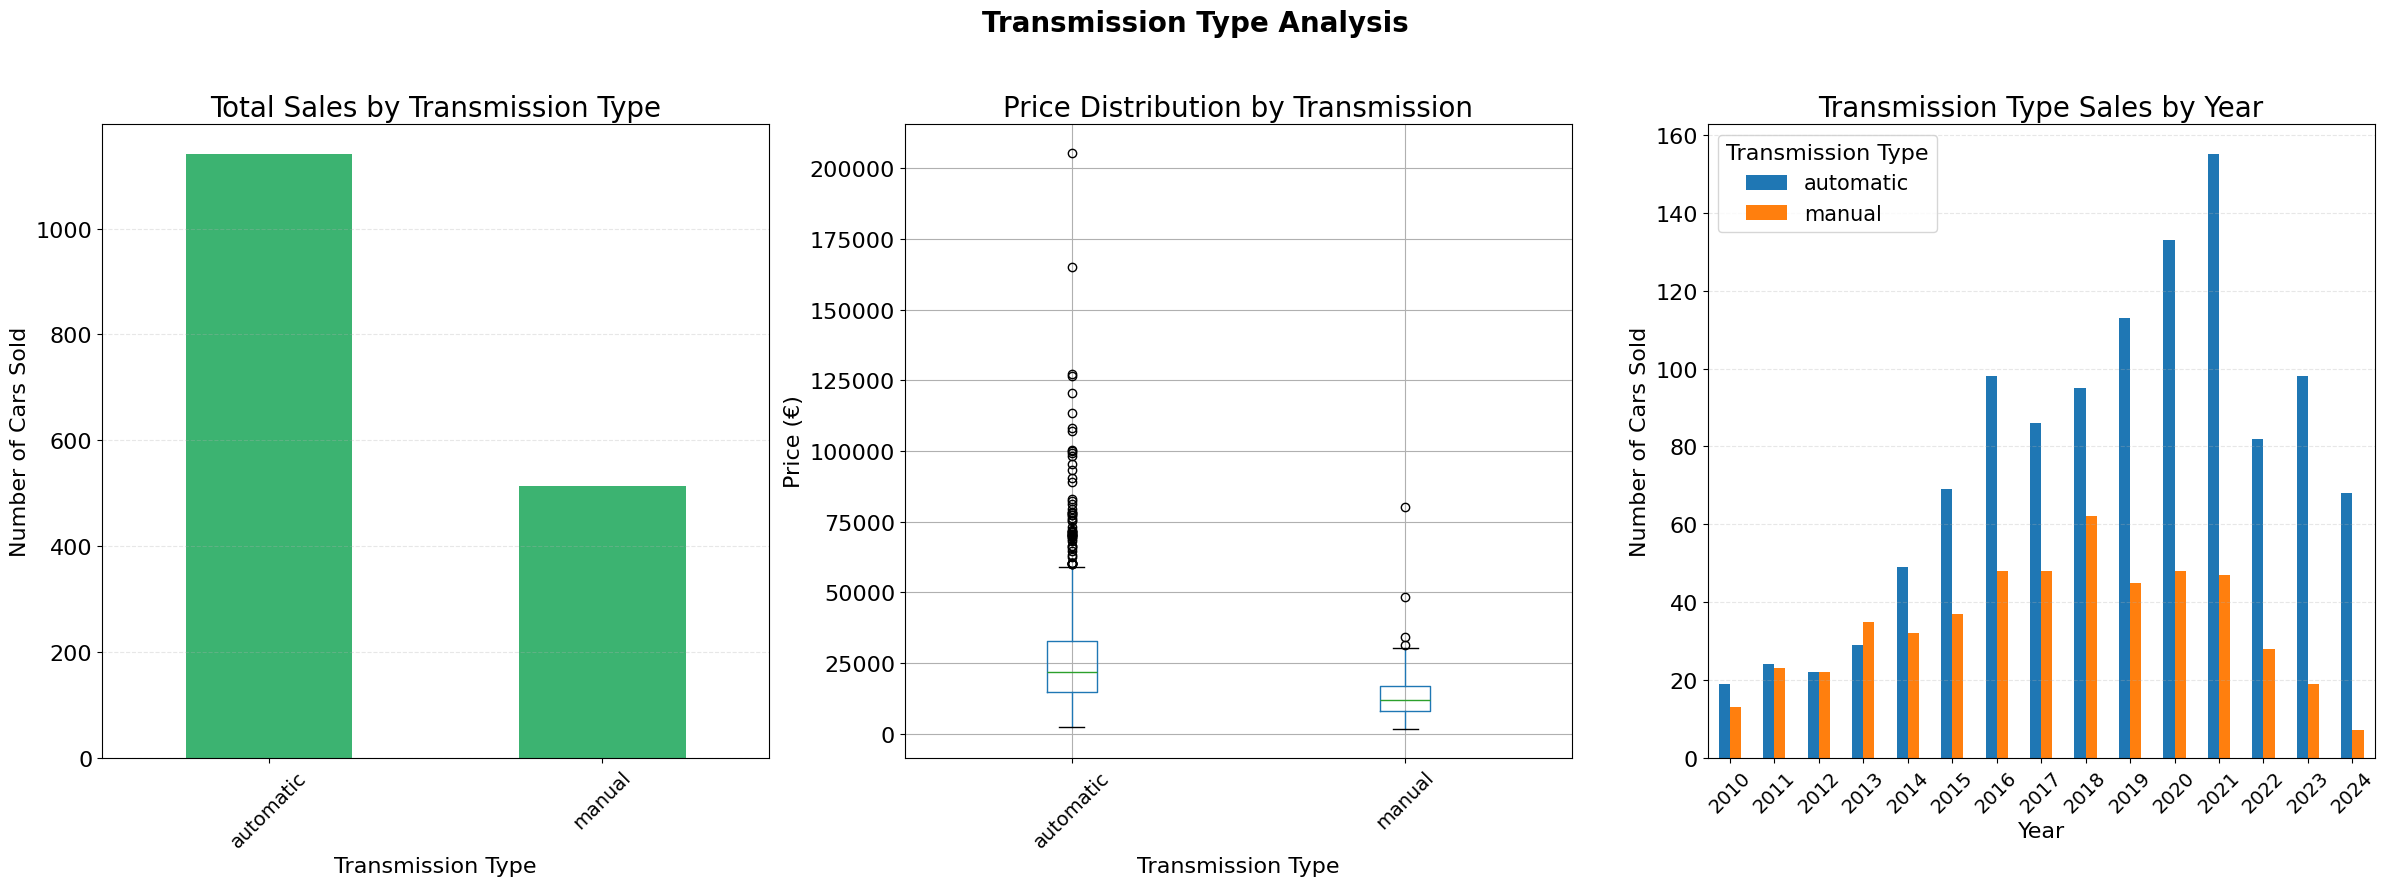

In [8]:
# Do the same for transmission type

# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Transmission Type Analysis', fontsize=20, fontweight='bold', y=0.98)

df["Transmission Type"].value_counts().plot(kind="bar", ax = axes[0], color='mediumseagreen') 
axes[0].set_title('Total Sales by Transmission Type', fontsize=20)
axes[0].set_xlabel('Transmission Type', fontsize=16)
axes[0].set_ylabel('Number of Cars Sold', fontsize=16)
axes[0].tick_params(axis='x', rotation=45, labelsize=14)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')


df.boxplot(column="Price",
           by="Transmission Type",
           ax = axes[1])
axes[1].set_title('Price Distribution by Transmission', fontsize=20)
axes[1].set_xlabel('Transmission Type', fontsize=16)
axes[1].set_ylabel('Price (€)', fontsize=16)
axes[1].tick_params(axis='x', rotation=45, labelsize=14)
axes[1].tick_params(axis='y', labelsize=16)
fig.canvas.draw()

df.groupby("Year")["Transmission Type"].value_counts().unstack().plot(kind="bar", ax= axes[2])
axes[2].set_title('Transmission Type Sales by Year', fontsize=20)
axes[2].set_xlabel('Year', fontsize=16)
axes[2].set_ylabel('Number of Cars Sold', fontsize=16)
axes[2].tick_params(axis='x', rotation=45, labelsize=14)
axes[2].tick_params(axis='y', labelsize=16)
axes[2].grid(True, axis='y', alpha=0.3, linestyle='--')
axes[2].legend(title="Transmission Type", fontsize=15, title_fontsize=16)
fig.suptitle('Transmission Type Analysis', fontsize=20, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.95])

# Discussion

The first plot shows that austomatic vehicles are far more popular and dominate total sales. The price distribution indicates that automatic cars also have a large price range, and appear to be right skewed. Manual cars tend to clust at lower price points, with less variablilty. It also shows that on average automatic cars are more expensive, with a mean price of € 26,450.36. The final plot also shows a steep drop off in the number of new manual cars being bought.

# Mileage Plots

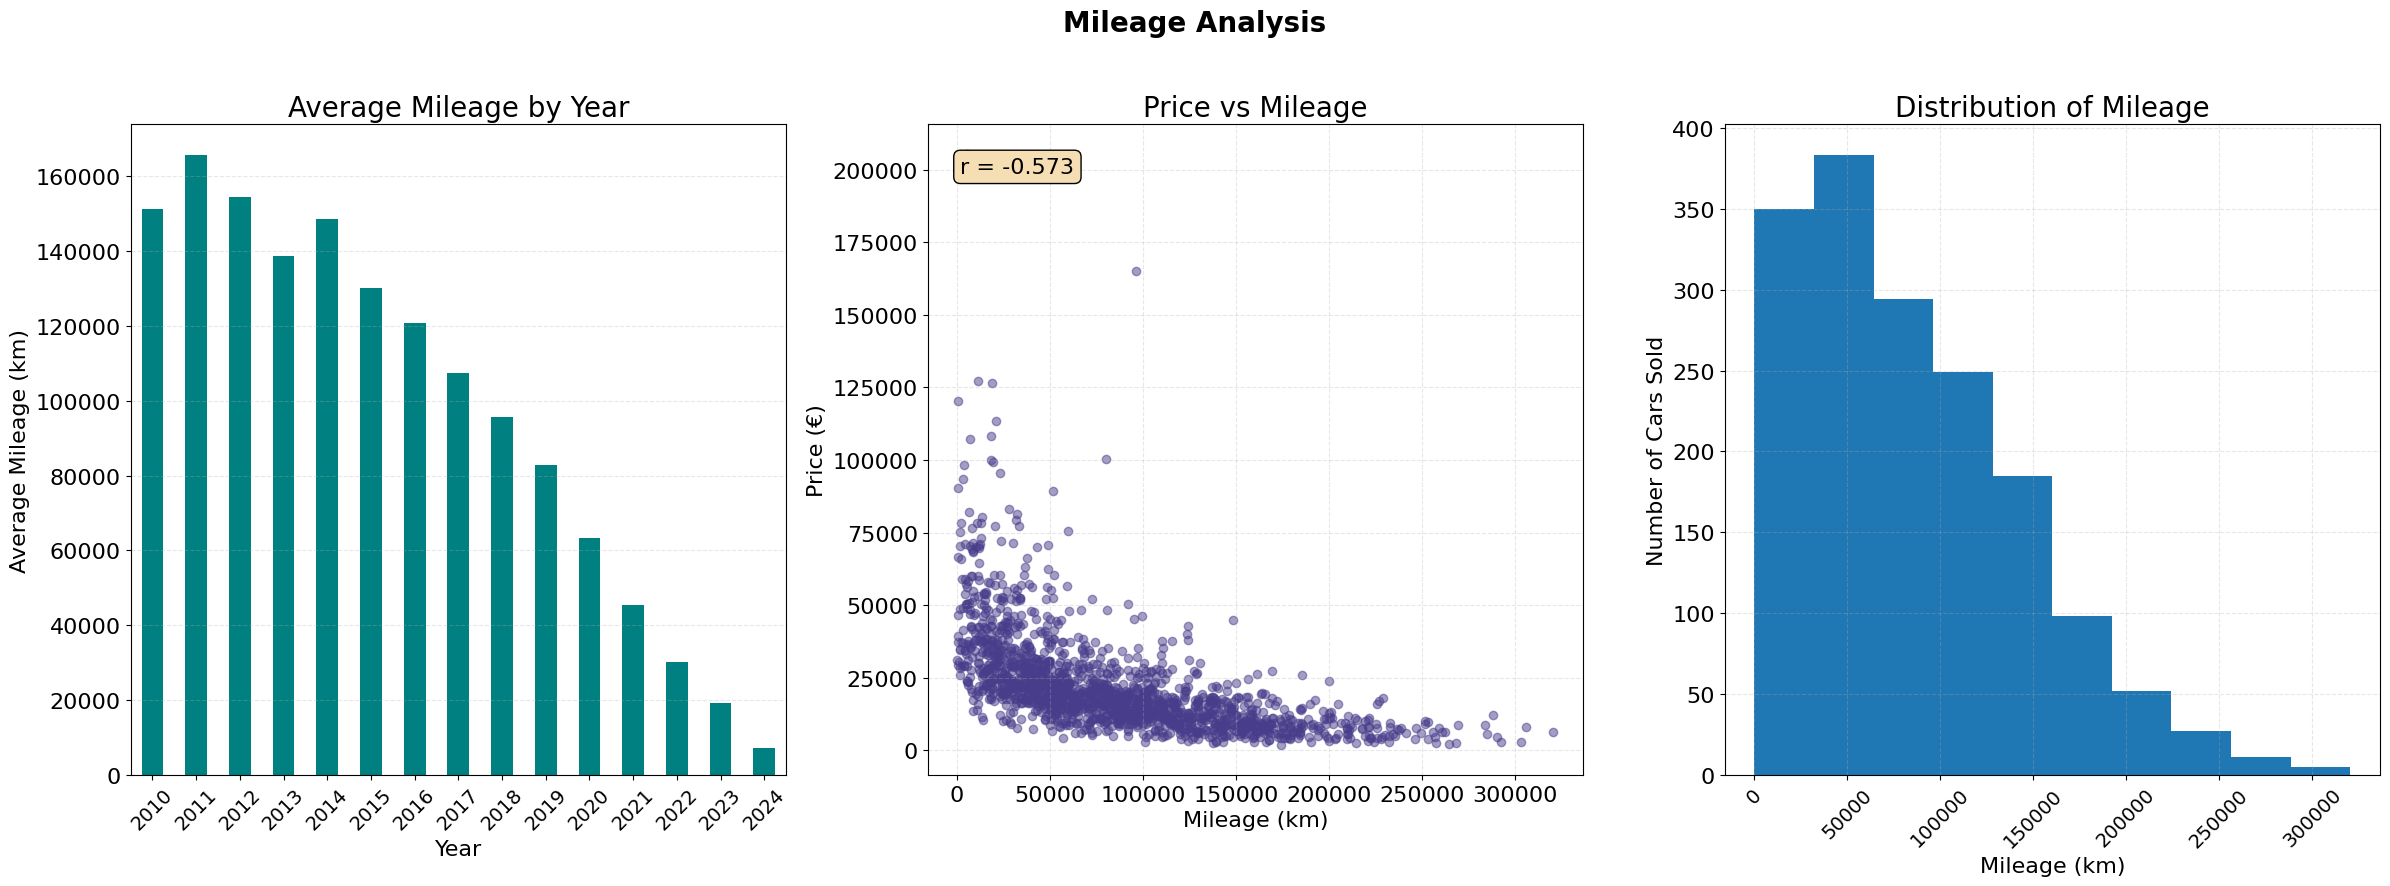

In [9]:
# Mileage plots
# 1. Mileage vs Year. #2. Mileage vs Price

# One figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Mileage Analysis', fontsize=20, fontweight='bold', y=0.98)

df.groupby("Year")["Mileage"].mean().plot(kind="bar", ax=axes[0], color='teal')
axes[0].set_title('Average Mileage by Year', fontsize=20)
axes[0].set_xlabel('Year', fontsize=16)
axes[0].set_ylabel('Average Mileage (km)', fontsize=16)
axes[0].tick_params(axis='x', rotation=45, labelsize=14)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')

# Mileage vs price scatter plot
axes[1].scatter(df["Mileage"], df["Price"], alpha=0.5, color='darkslateblue')
axes[1].set_title('Price vs Mileage', fontsize=20)
axes[1].set_xlabel('Mileage (km)', fontsize=16)
axes[1].set_ylabel('Price (€)', fontsize=16)
axes[1].tick_params(axis='both', labelsize=16)
axes[1].grid(True, alpha=0.3, linestyle='--')

# Calculate and display correlation coefficient
correlation = df["Mileage"].corr(df["Price"])
axes[1].text(0.05, 0.95, f'r = {correlation:.3f}', 
             transform=axes[1].transAxes, 
             fontsize=16, 
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat'))

df["Mileage"].plot(kind="hist", ax=axes[2])
axes[2].set_title('Distribution of Mileage', fontsize=20)
axes[2].set_xlabel('Mileage (km)', fontsize=16)
axes[2].set_ylabel('Number of Cars Sold', fontsize=16)
axes[2].tick_params(axis='x', rotation=45, labelsize=14)
axes[2].tick_params(axis='y', labelsize=16)
axes[2].grid(True, alpha=0.3, linestyle='--')


plt.tight_layout(rect=[0, 0, 1, 0.95])

## Dicussion
The plot on the left shows that unsurprisingly, mileage on newer cars is lower than on older cars, however it is not a linear relationship. If so, we would expect that cars manufactured in 2010 would have the highest mileage, however, in reality it is cars purchased in 2011. This could be due to the lower number of cars sold that were manufactured in that year, meaning it is not represantative of the true mileage.

The scatter plot of price vs mileage shows a negative correlation, where higher mileage cars tend to have lower prices. It is evident that there is a large initial drop off in price, indicating that as soon as a car has been driven it loses a considerable portion of its value. Overall, the pattern  demonstrates that mileage is an important factor car price, with value decreasing as mileage rises.

# Car Age Analysis

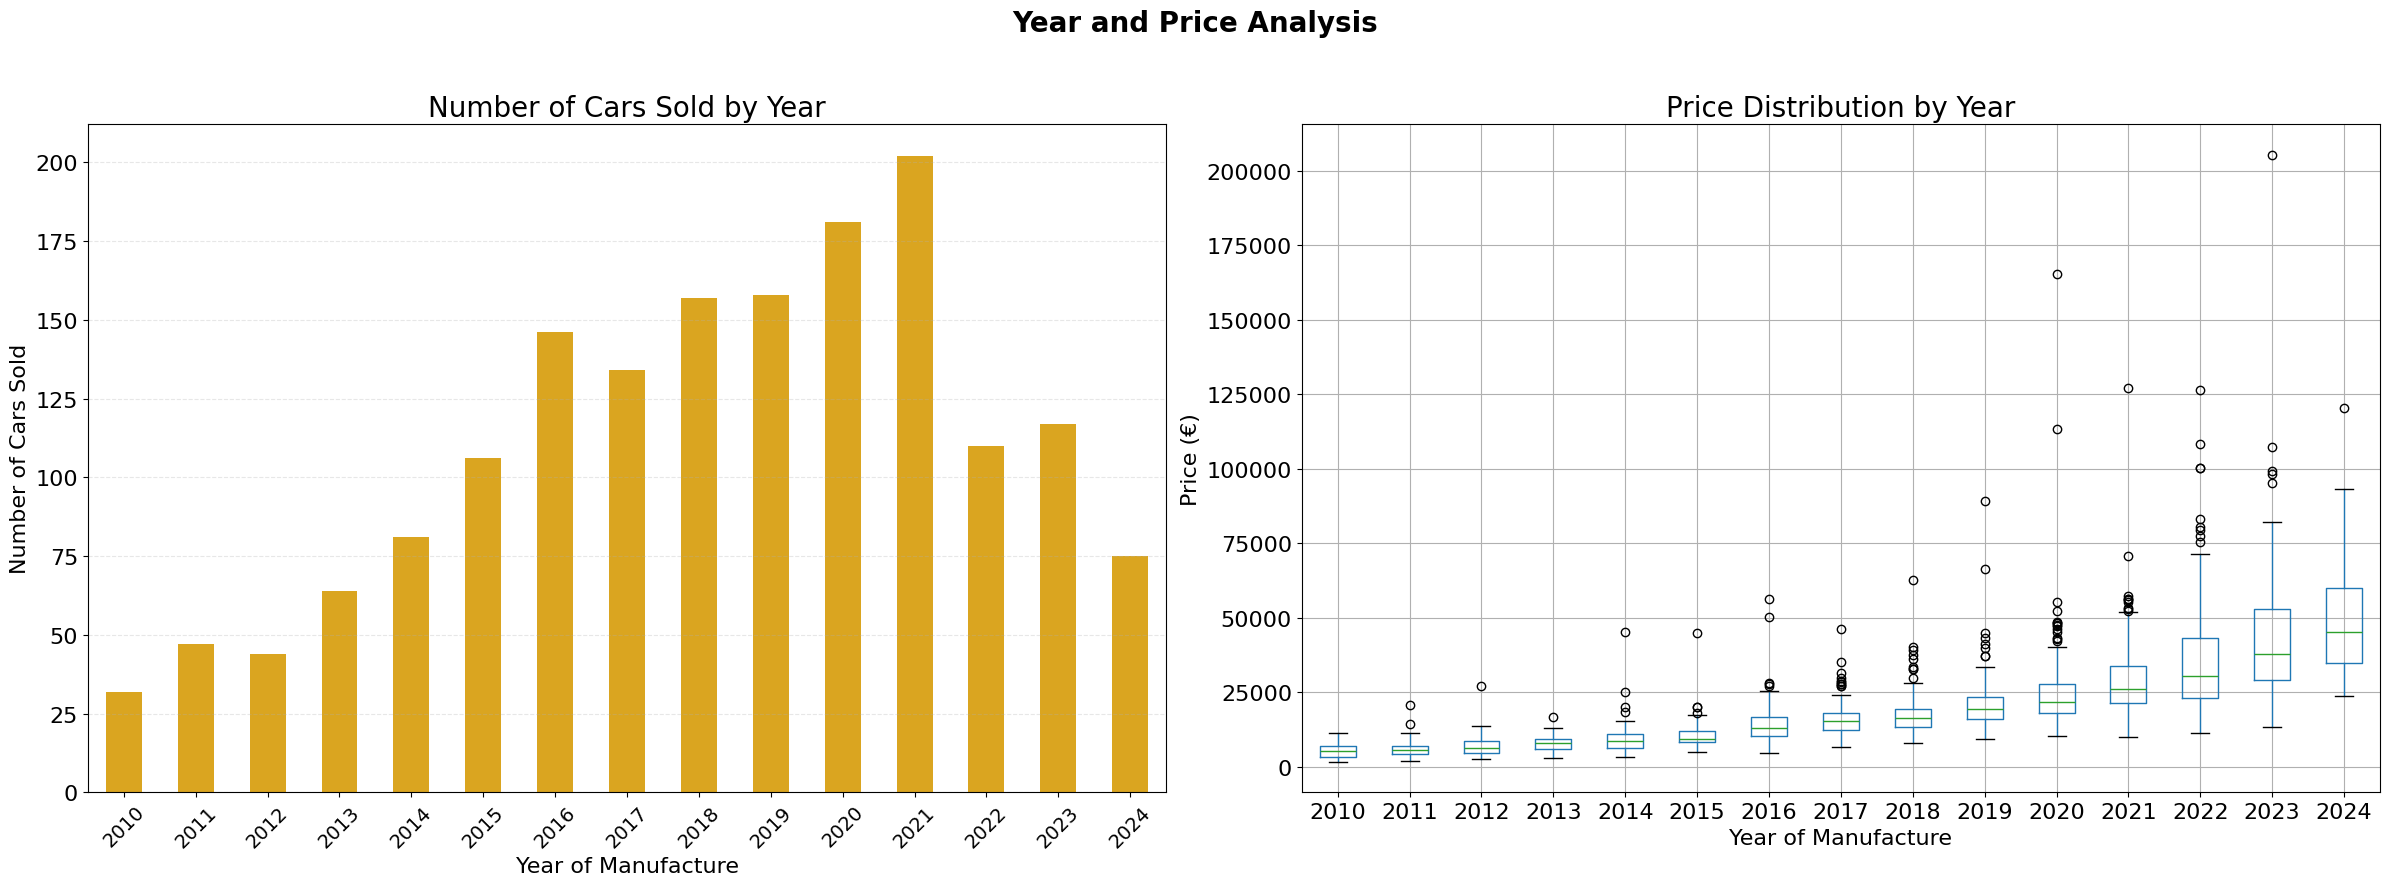

In [10]:
# Prices plots
# 1. Distribution of how old cars are, # 2. Price distribution by year
fig, axes = plt.subplots(1, 2, figsize=(24, 9))
fig.suptitle('Year and Price Analysis', fontsize=20, fontweight='bold', y=0.98)

df["Year"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color='goldenrod')
axes[0].set_title('Number of Cars Sold by Year', fontsize=20)
axes[0].set_xlabel('Year of Manufacture', fontsize=16)
axes[0].set_ylabel('Number of Cars Sold', fontsize=16)
axes[0].tick_params(axis='x', rotation=45, labelsize=14)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')

# Year vs price box plot
df.boxplot(column="Price", by="Year", ax=axes[1])
axes[1].set_title('Price Distribution by Year', fontsize=20)
axes[1].set_xlabel('Year of Manufacture', fontsize=16)
axes[1].set_ylabel('Price (€)', fontsize=16)
axes[1].tick_params(axis='both', labelsize=16)
fig.canvas.draw()
fig.suptitle('Year and Price Analysis', fontsize=20, fontweight='bold', y=0.98)


plt.tight_layout(rect=[0, 0, 1, 0.95])

## Discussion
The data shows that cars manufactured in 2021 are the most popular. Newer cars are less popular, perhaps due to their higher price points. There is also a drop off in the number of older cars sold, perhaps due to their lack of reliability. The plot on the right shows that newer cars are indeed more expensive, and the range of prices increases as the cars get newer. 

# Car Sales Seasonality

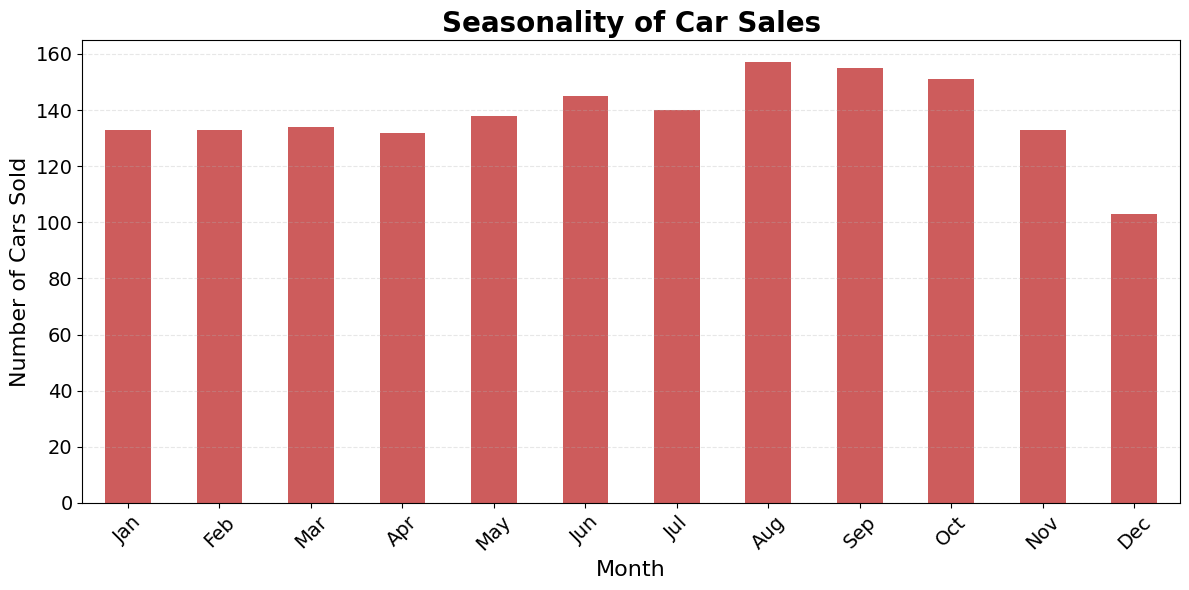

In [11]:
# Are car sales seasonal?
fig, ax = plt.subplots(figsize=(12, 6))
month_counts = df["Date of Sale"].dt.month.value_counts().sort_index()
month_counts.plot(kind="bar", ax=ax, color='indianred')
ax.set_title('Seasonality of Car Sales', fontsize=20, fontweight='bold')
ax.set_xlabel('Month', fontsize=16)
ax.set_ylabel('Number of Cars Sold', fontsize=16)
ax.tick_params(axis='both', labelsize=14)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()

## Discussion
This plot shows that car sales are seasonal, with Augst being the most popular month to buy a car. There is a discontinuity between December and Januaray, which is perhaps due to people wanting to purchase a brand new car at the start of the year. Perhaps people don't want to purchase a new car in December, as a newer model will be coming out in the new year.

# Counties with Big Cities Analysis

Text(0.5, 0.98, 'Big City vs Rural County Comparison')

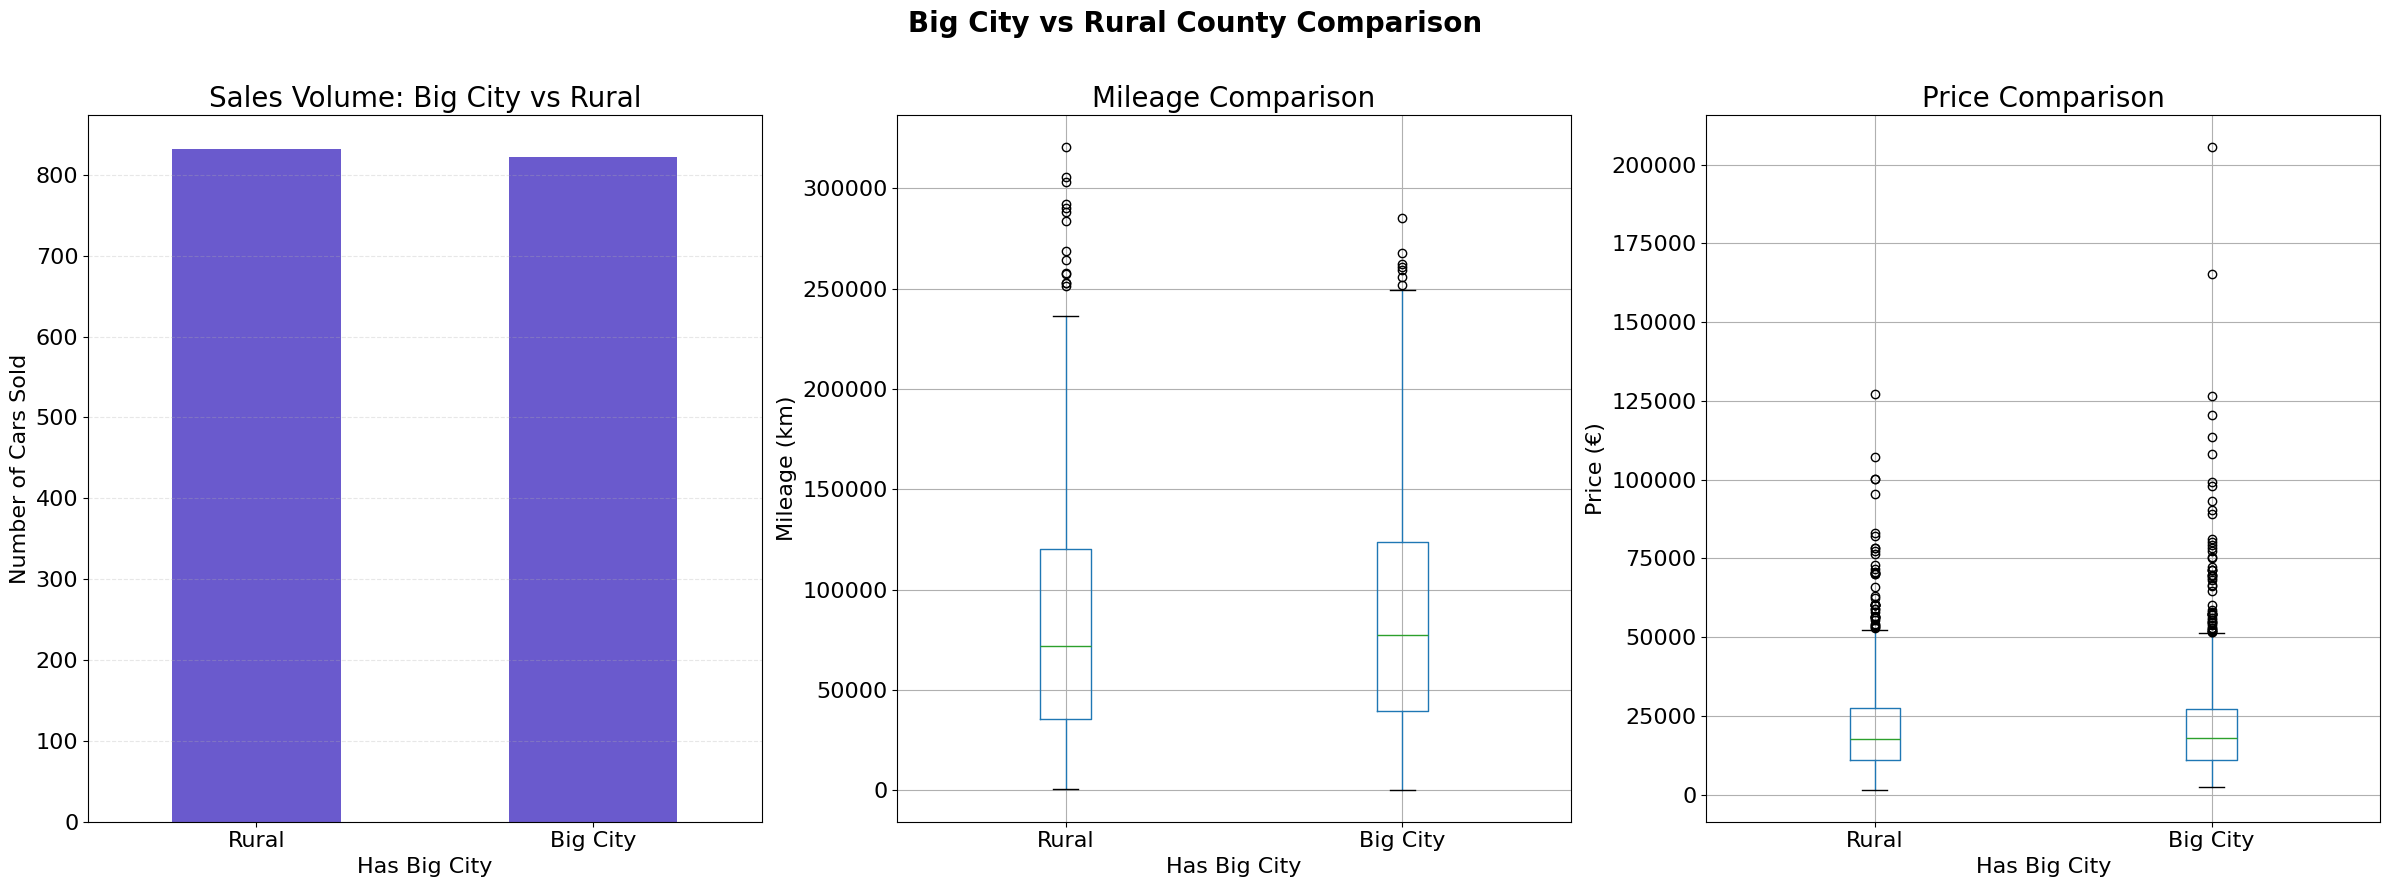

In [12]:
# Compare the mileage in counties with and without big cities
# One figure with 2 subplots
fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Big City vs Rural County Comparison', fontsize=20, fontweight='bold', y=0.98)

counties_with_big_cities = ["Dublin", "Limerick", "Cork", "Galway"]

df["Has Big City"] = df["Sale Location"].isin(counties_with_big_cities)

# Compare the number of cars sold with and without big cities
df["Has Big City"].value_counts().plot(kind="bar", ax=axes[0], color='slateblue')
axes[0].set_title('Sales Volume: Big City vs Rural', fontsize=20)
axes[0].set_xlabel('Has Big City', fontsize=16)
axes[0].set_ylabel('Number of Cars Sold', fontsize=16)
axes[0].tick_params(axis='both', labelsize=16)
axes[0].set_xticklabels(['Rural', 'Big City'], rotation=0)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')

df.boxplot(column="Mileage", by="Has Big City", ax=axes[1])
axes[1].set_title('Mileage Comparison', fontsize=20)
axes[1].set_xlabel('Has Big City', fontsize=16)
axes[1].set_ylabel('Mileage (km)', fontsize=16)
axes[1].tick_params(axis='both', labelsize=16)
axes[1].set_xticklabels(['Rural', 'Big City'], rotation=0)

# Compare prices in counties with and without big city
df.boxplot(column="Price", by="Has Big City", ax=axes[2])
axes[2].set_title('Price Comparison', fontsize=20)
axes[2].set_xlabel('Has Big City', fontsize=16)
axes[2].set_ylabel('Price (€)', fontsize=16)
axes[2].tick_params(axis='both', labelsize=16)
axes[2].set_xticklabels(['Rural', 'Big City'], rotation=0)
fig.canvas.draw()

plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.suptitle('Big City vs Rural County Comparison', fontsize=20, fontweight='bold', y=0.98)


## Discussion
The figure on the left shows that roughly the same number of cars are sold in counties which contain a big city and those that do not. On average, cars purchased in counties with big cities tend to have slightly higher mileage, however, there is a larger distribution of mileage in counties without a big city. On average, the price of cars sold is roughly the same, however counties with big cities have more statistical outliers, indicating that more  very expensive cars are purchased in counties with big cities.

# Number of Doors Analysis

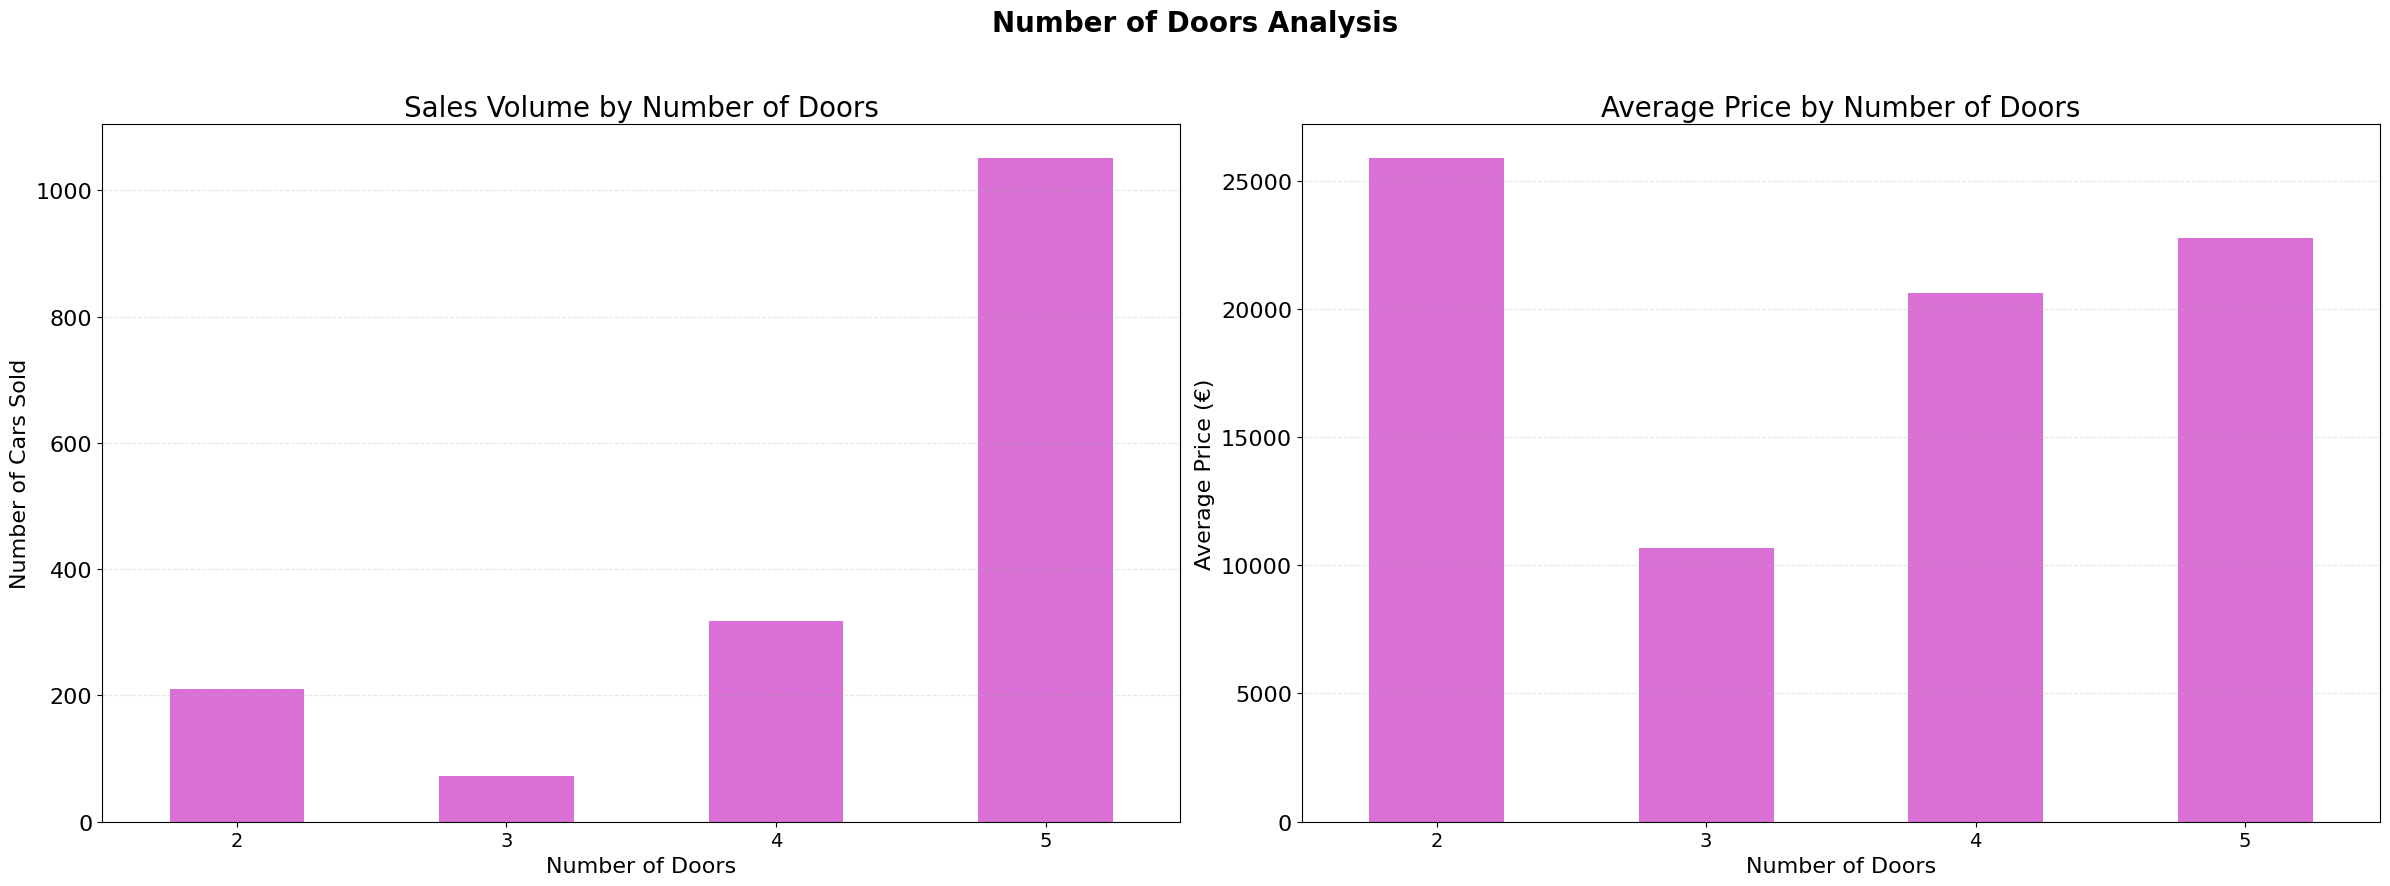

In [13]:
# Number of doors analysis
# 1. Number of cars sold by number of doors, 2. Price by number of doors

# One figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(24, 9))
fig.suptitle('Number of Doors Analysis', fontsize=20, fontweight='bold', y=0.98)
df["Number of Doors"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color='orchid')
axes[0].set_title('Sales Volume by Number of Doors', fontsize=20)
axes[0].set_xlabel('Number of Doors', fontsize=16)
axes[0].set_ylabel('Number of Cars Sold', fontsize=16)
axes[0].tick_params(axis='x', rotation=0, labelsize=14)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')

# Average price per number of doors bar plot
avg_price_by_doors = df.groupby("Number of Doors")["Price"].mean()
avg_price_by_doors.plot(kind="bar", ax=axes[1], color='orchid')
axes[1].set_title('Average Price by Number of Doors', fontsize=20)
axes[1].set_xlabel('Number of Doors', fontsize=16)
axes[1].set_ylabel('Average Price (€)', fontsize=16)
axes[1].tick_params(axis='x', rotation=0, labelsize=14)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].grid(True, axis='y', alpha=0.3, linestyle='--')


plt.tight_layout(rect=[0, 0, 1, 0.95])

# Discussion
The dataset shows that the most common number of doors in a car is 5 (including the boot), which makes up 63.6% of cars sold. However, it is likely that cars labled as 4 doors actually have 5 doors including the boot. If these are put together, it shows that 82.8% of cars sold have 5 doors. Cars with 2 doors are the most expensive, with an average price of €25898.73. 

# Previous Owners Analysis

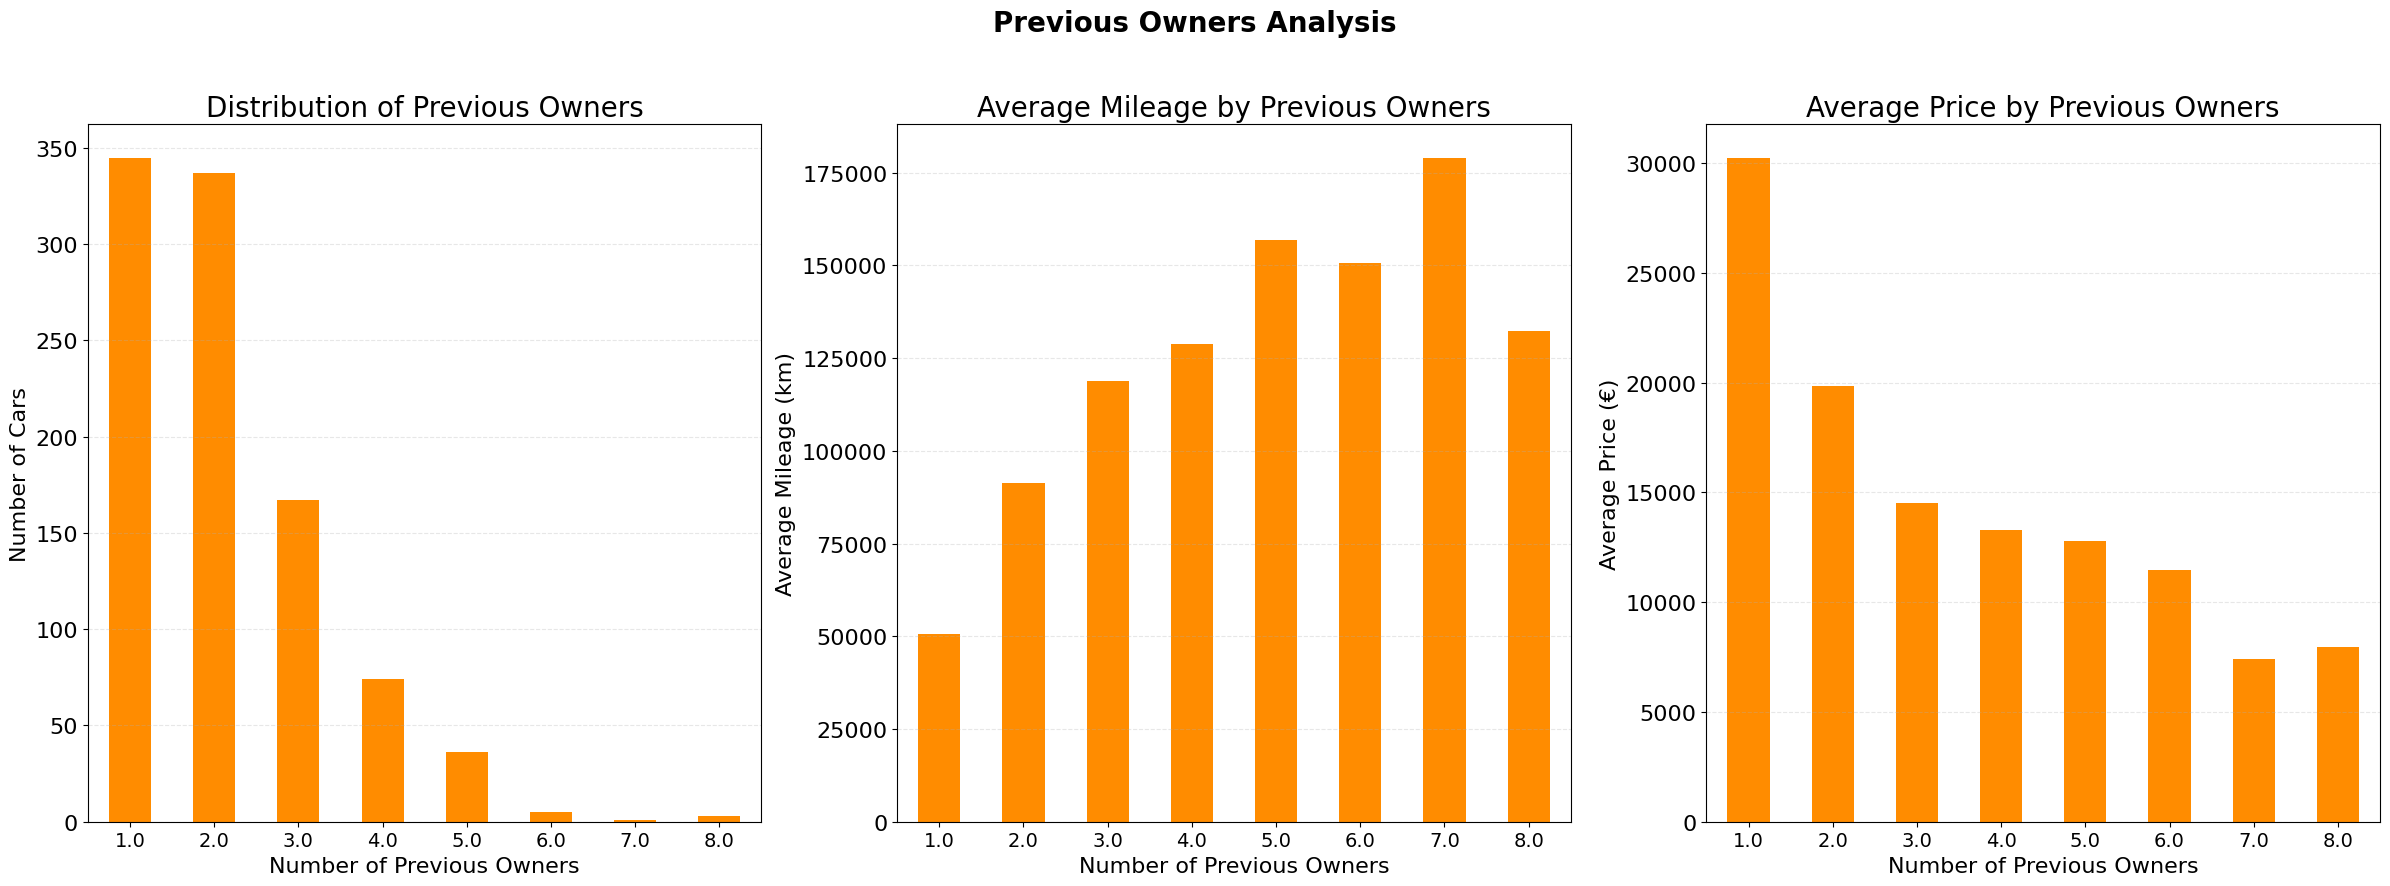

In [14]:
# Plots of Previous owners
# 1. Plots of previous owners vs Mileage, # 2. Previous owners vs Price, #3. Distribution of previous owners


fig, axes = plt.subplots(1, 3, figsize=(24, 9))
fig.suptitle('Previous Owners Analysis', fontsize=20, fontweight='bold', y=0.98)

df["Previous Owners"].value_counts().sort_index().plot(kind="bar", ax = axes[0], color='darkorange') 
axes[0].set_title('Distribution of Previous Owners', fontsize=20)
axes[0].set_xlabel('Number of Previous Owners', fontsize=16)
axes[0].set_ylabel('Number of Cars', fontsize=16)
axes[0].tick_params(axis='x', rotation=0, labelsize=14)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')

df.groupby("Previous Owners")["Mileage"].mean().plot(kind="bar", ax=axes[1], color='darkorange')
axes[1].set_title('Average Mileage by Previous Owners', fontsize=20)
axes[1].set_xlabel('Number of Previous Owners', fontsize=16)
axes[1].set_ylabel('Average Mileage (km)', fontsize=16)
axes[1].tick_params(axis='x', rotation=0, labelsize=14)
axes[1].tick_params(axis='y', labelsize=16)
axes[1].grid(True, axis='y', alpha=0.3, linestyle='--')

df.groupby("Previous Owners")["Price"].mean().plot(kind="bar", ax=axes[2], color='darkorange')
axes[2].set_title('Average Price by Previous Owners', fontsize=20)
axes[2].set_xlabel('Number of Previous Owners', fontsize=16)
axes[2].set_ylabel('Average Price (€)', fontsize=16)
axes[2].tick_params(axis='x', rotation=0, labelsize=14)
axes[2].tick_params(axis='y', labelsize=16)
axes[2].grid(True, axis='y', alpha=0.3, linestyle='--')


plt.tight_layout(rect=[0, 0, 1, 0.95])

# Discussion
The graph on the left shows that most cars have either 1 or 2 previous owners, with a steep drop off after 3 previous owners. As expected, the average mileage increases significantly as the number of previous owners increases. There is also a steep drop off in price once the car has have more than 1 owner.

# Aesthetics Analysis

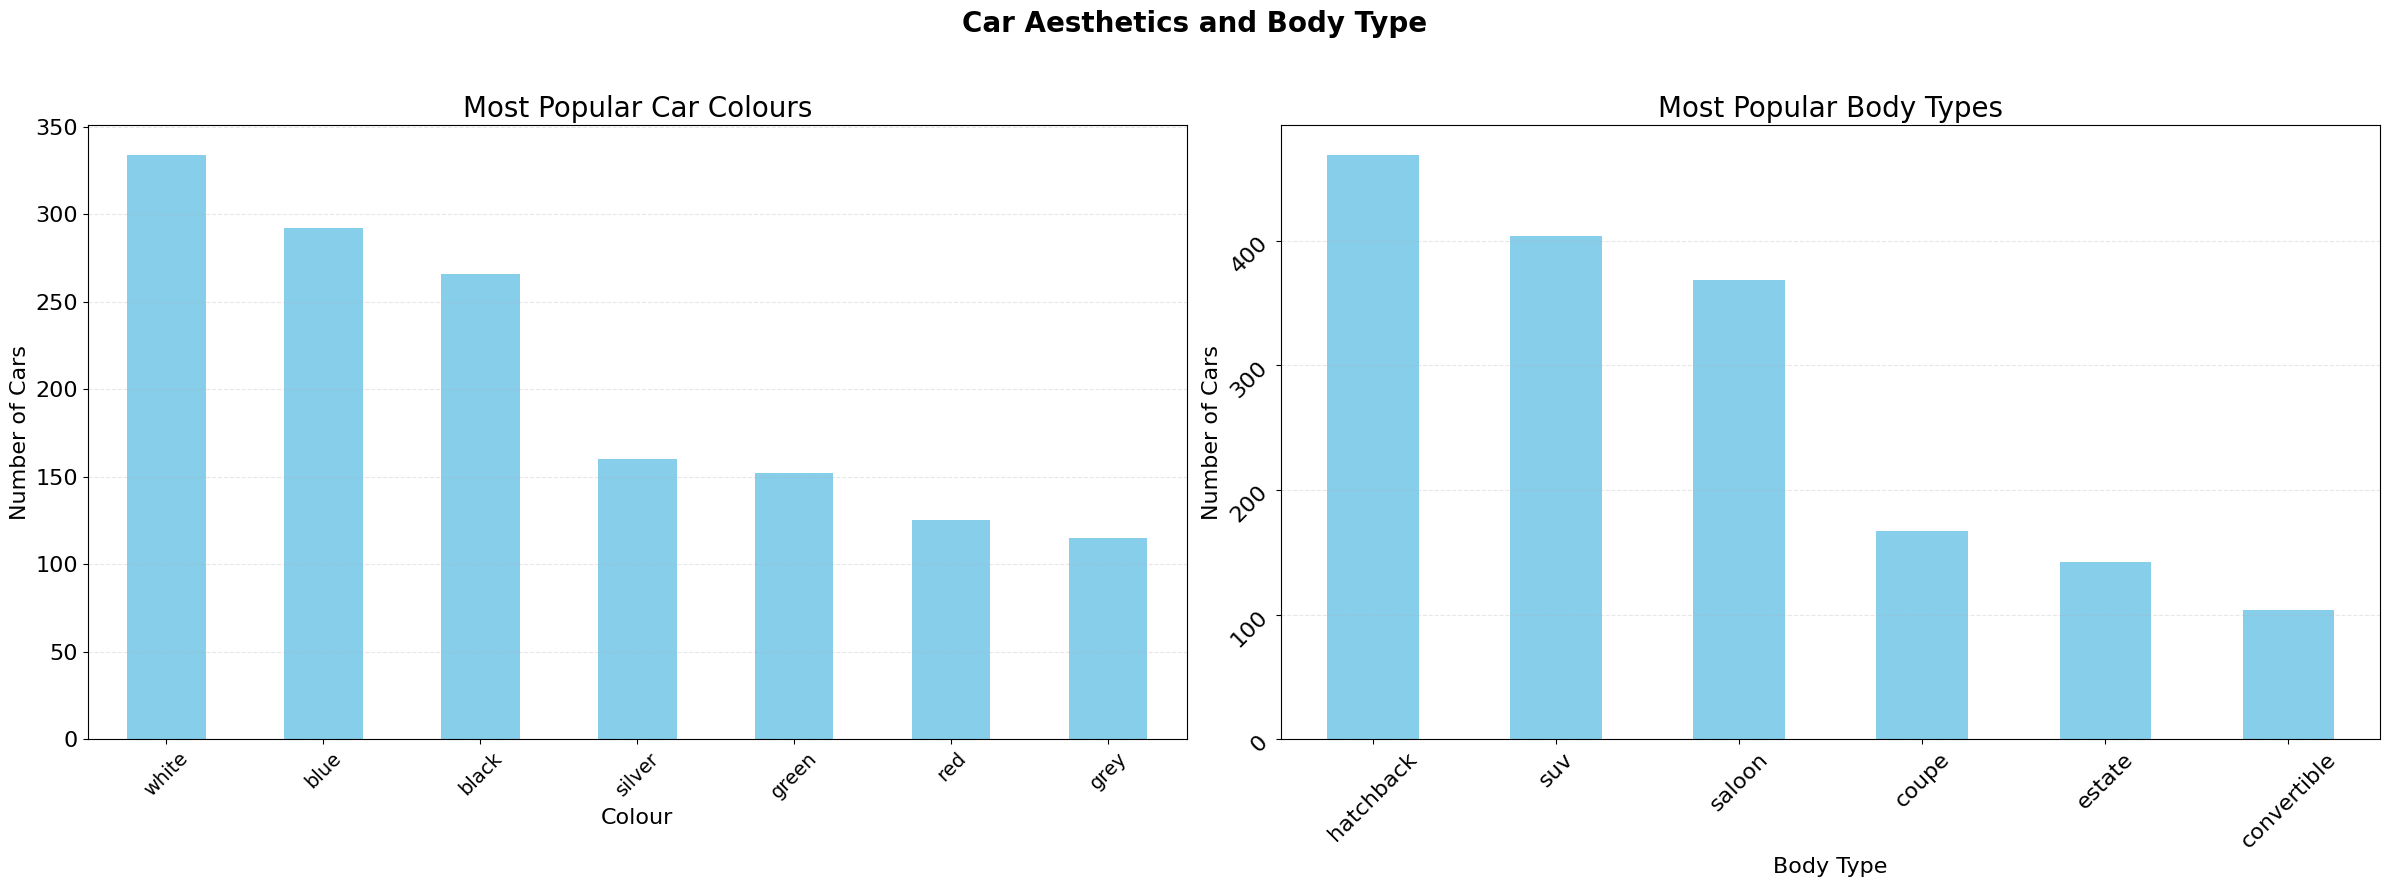

In [15]:
# Asethic plots
fig, axes = plt.subplots(1, 2, figsize=(24, 9))
fig.suptitle('Car Aesthetics and Body Type', fontsize=20, fontweight='bold', y=0.98)

# 1. Most popular Colours
df["Colour"].value_counts().plot(kind="bar", ax = axes[0], color='skyblue')
axes[0].set_title('Most Popular Car Colours', fontsize=20)
axes[0].set_xlabel('Colour', fontsize=16)
axes[0].set_ylabel('Number of Cars', fontsize=16)
axes[0].tick_params(axis='x', rotation=45, labelsize=14)
axes[0].tick_params(axis='y', labelsize=16)
axes[0].grid(True, axis='y', alpha=0.3, linestyle='--')

# Most Popular body types
df["Body"].value_counts().plot(kind="bar", ax=axes[1], color='skyblue')
axes[1].set_title('Most Popular Body Types', fontsize=20)
axes[1].set_xlabel('Body Type', fontsize=16)
axes[1].set_ylabel('Number of Cars', fontsize=16)
axes[1].tick_params(axis='both', labelsize=16, rotation=45)
axes[1].grid(True, axis='y', alpha=0.3, linestyle='--')


plt.tight_layout(rect=[0, 0, 1, 0.95])

## Discussion
The data shows that the most popular colour of car is white, making up 20.19% of all cars sold. Grey is the least popular with only 6% of cars sold. Hatchbacks are the most popular body type, accounting for 28.4% of total car sales, and convertables are the least popular, representing only 6% of car sales.

---

# Challenges in Scraping Data


**1. Multiple Pages**

The car database contained multiple page, with a different page per brand. Navigating through these pages was difficult at first, as it involved creating a list of brands by analysing the HTML.

**2. Multiple Subpages (Removing Duplicates)**

Each brand page contained multiple subpages. Not all brand contained the same number of subpages, so a list of them had to be found by analysing the nav element at the bottom of the page. Duplicate links had to be removed.

**3. Find Correct Elements**

Finding the correct elements which stored the car info in the HTML page was trick at first. It involved using inspect element in the browser to find the correct tag.

**4. Finding Appropriate structure for data storage**

Storing the data in an appropriate data structure, such that it could be written to JSON was initally challenging.

# Challanges in Cleaning dataset

**1. Inconsistent Date Types**
Several of the dates are in different formats, which was a challenge when cleanin the dataset. Using the format="mixed" argument allowed the different formats to all be converted to a DD-MM-YYYY format.

**2. Price Parsing**
Multiple symbols for euros were used, including EUR and €. These were all removed, along with any whitespaces, and the value was converted to a float. Also, any commas in the price had to be removed.

**3. Mileage Data**
The mileage data is often inconsitent, with some using "km" and some using "kms". These string were removed (importantly kms was removed before km, as otherwise this would leave an "s") and the value was converted to a float.

**4. Transmission Data**
The transmission data contains some irregularities, such as some automatic cars simply being recorded as "auto".

**5. Fuel Data**
Some diesel and petrol hybrid cars are recorded differntly. To account for this, the name was checked to see if it includes both "hybrid" and either "petrol" or "diesel", and if so it was replaced by either "diesel-hybrid" or "petrol-hybrid".

**6. Year Data**
The year data was all converted to integers

**7. Sale Location Data**
Leading whitespaces had to be removed from the dale location.

**8. Body Data**
The body field sometimes contains "estat" instead of "estate" and "S.U.V." instead of "suv". These were standardised, and the body type was set to lower case.

**9. Description Field Data**
Some description fields include data for colour, number of doors, and the number of previous owners. This data was isolated and recorded in their own columns. These columns contain some missing values. For the number of doors, 5 was filled in as a default, as most cars have 5 doors including the boot. 

---



# Key Insights

Here is a brief recap of the most insightful observations from the data analysis


**1. County Analysis**

Analysing the different counties reveals that Dublin is the county with the most car sales. Cavan is the most expensive county to buy a car, and Longford is the county with the highest average mileage per car sold

**2. Fuel Type** 

The fuel type analysis showed that diesel is the most popular fuel type. Petrol cars have a large variance in price, and the data tends to be right skewed. Newer electric and hybrid cars have been gaining popularity. 

**3. Brands** 

Merecedes is the most popular brand, and is also the most expensive. People buy older BMWs and newer Toyotas.

**4. Transmission Type** 

Automatic transmission is by far the most popular type. Manual cars have been steadily losing market share, as people buy fewer new manual cars.

**5. Mileage Analysis** 

Mileage is negatively correlated with price. As mileage increases, the average price of the vehicle sold goes down. As soon as the car is driven, the price goes down considerably. Mileage data is also right skewed.

**6. Manufacture year analysis** 

Analysing the year of manufacturing shows that people don't tend to buy very old or very new cars, with 2021 being the most popular year. Newer cars tend to have a larger variation in price, and are naturally more expensive.

**7. Seasonality** 

Car sale are evidently seasonal, with August being the most popular month to buy a car. There is a spike in January, where people want to get the newer model of their car.

**8. Big Cities** 

Although the average price is fairly consistent, more very expensive cars are sold in counties with contain big cities.

**9. Number of doors** 

The most popular number of doors for a car is 5, including the boot. Cars with 2 doors are the most expensive.

**10. Previous Owners** 

Most cars sold have either 1 and 2 previous owners. After that, the price drops considerably.

**11. Aesthetics** 

White cars are the most popular colours and hatchbacks are the most popular body type.





# Potential Future Analysis

**1. Compare number of car sold with publically available CSO data**

The central statistcs office has data on the population in each county in JSON and CSV formats. It could be intersting to see the correlation between this and the number of cars sold in each county.

**2. Urban vs Rural Car Age**

Analysis could be performed on the age of cars purchased in rural or urban enviornments. One might expect cars in rural areas to be older, but it would be nice to quantify this.

**3. Quantify What Has the Biggest Impact on Vehicle Price**

It would be interesting to quantify exactly which data point has the biggest effect on vehicle price. It could be mileage, the number of previous owners or the age of the vehicle.

**4. Machine Learning Regression**



